In [1]:
!pip install -r requirements.txt --quiet


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
%matplotlib inline
import pymc as pm
import numpy as np
import pandas as pd
from scipy.stats import norm, binom, bernoulli, lognorm, betabinom
from scipy.stats import beta as beta_dist
from scipy.special import expit as inv_logit
from scipy.special import logit ,logsumexp
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import arviz as az
import networkx as nx
import xarray as xr

import collections.abc
collections.Iterable = collections.abc.Iterable
from causalgraphicalmodels import CausalGraphicalModel
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()
from matplotlib.patches import FancyArrowPatch

import warnings
warnings.filterwarnings('ignore')


%config InlineBackend.figure_format = 'retina'

plt.style.use(['seaborn-v0_8-darkgrid','seaborn-v0_8-colorblind'])

#### Code 14.1

In [94]:
a = 3.5
b = -1
sigma_a = 1
sigma_b = .5
rho = -.7

#### Code 14.2

In [95]:
Mu = [a,b]

#### Code 14.3

In [96]:
cov_ab = sigma_a * sigma_b * rho
Sigma = np.array([sigma_a ** 2, cov_ab, cov_ab, sigma_b**2]).reshape(-1,2)
Sigma

array([[ 1.  , -0.35],
       [-0.35,  0.25]])

#### Code 14.4

In [97]:
np.array([1,2,3,4]).reshape(-1,2)

array([[1, 2],
       [3, 4]])

#### Code 14.5

In [98]:
sigmas = [sigma_a, sigma_b]
Rho = np.array([1,rho,rho,1]).reshape(-1,2)

# now matrix multiply by the covariance matrix 
Sigma = np.diag(sigmas) @ Rho @ np.diag(sigmas)

#### Code 14.6

In [99]:
N_cafes = 20

#### Code 14.7

In [100]:
np.random.seed(5)

vary_effects = np.random.multivariate_normal(Mu, Sigma, N_cafes)

vary_effects

array([[ 3.02149593, -0.9304358 ],
       [ 1.05666673, -0.12762876],
       [ 3.58546284, -0.46432203],
       [ 4.3297356 , -1.53991745],
       [ 3.27332508, -1.02933771],
       [ 4.65859716, -1.5303893 ],
       [ 3.93018946, -0.9524405 ],
       [ 5.06625508, -1.869279  ],
       [ 2.58529637,  0.0287956 ],
       [ 5.07890482, -1.39033508],
       [ 4.36801698, -1.65042937],
       [ 4.31342478, -1.47263713],
       [ 2.59854231, -0.38835499],
       [ 3.39670791, -1.09000246],
       [ 3.48373345, -1.03170127],
       [ 2.63542057, -0.88644913],
       [ 3.49374238, -1.03389681],
       [ 3.58250316, -0.94285315],
       [ 3.46768242, -0.50699357],
       [ 3.77789108, -0.54770738]])

#### Code 14.8

In [101]:
a_cafe = vary_effects[:,0]

b_cafe = vary_effects[:,1]


#### Code 14.9

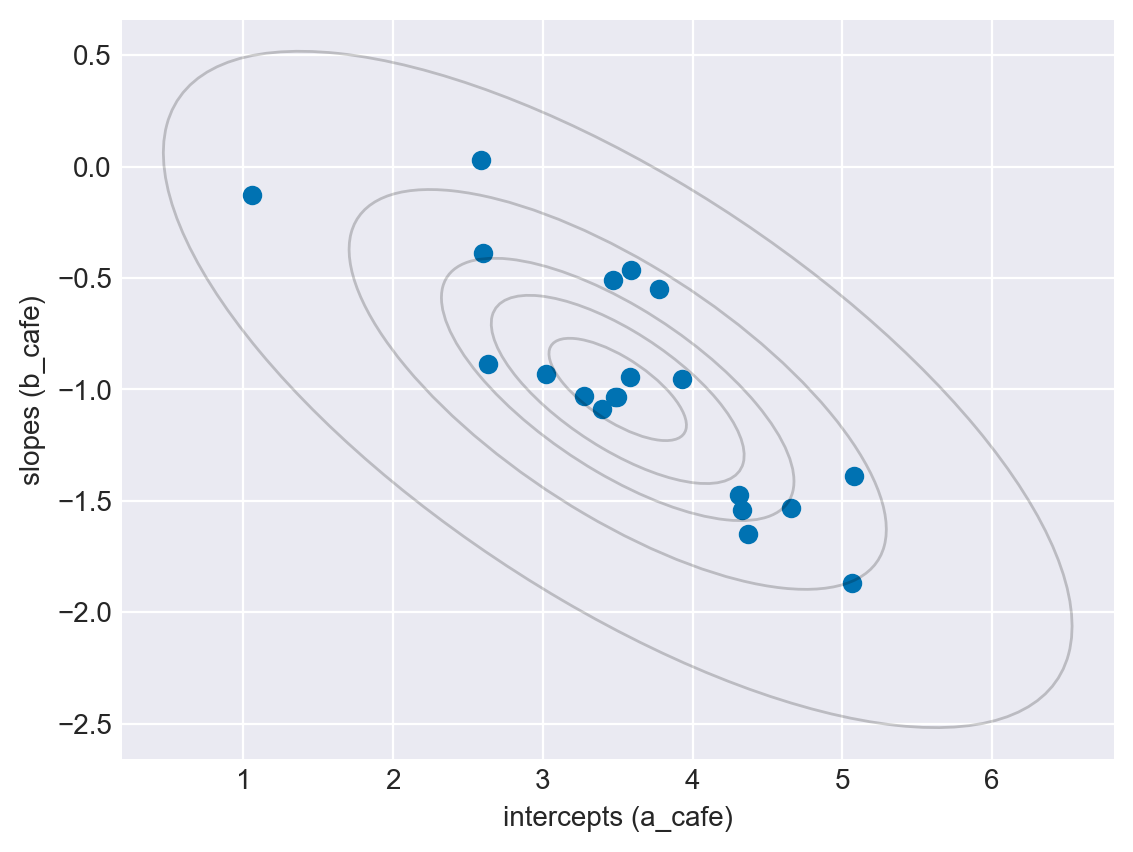

In [102]:
fig, ax = plt.subplots()
ax.scatter(a_cafe, b_cafe)
ax.set_xlabel('intercepts (a_cafe)')
ax.set_ylabel('slopes (b_cafe)')

from matplotlib.patches import Ellipse
from scipy.stats import chi2  

# Build the covariance matrix from your parameters
cov_ab = sigma_a * sigma_b * rho
Sigma = np.array([[sigma_a**2, cov_ab],
                  [cov_ab, sigma_b**2]])

# Compute eigenvalues and eigenvectors for rotation
eigenvalues, eigenvectors = np.linalg.eig(Sigma)
angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))

for l in [0.1, 0.3, 0.5, 0.8, 0.99]:
    scale = np.sqrt(chi2.ppf(l, df=2))
    width = 2 * scale * np.sqrt(eigenvalues[0])
    height = 2 * scale * np.sqrt(eigenvalues[1])
    
    ellipse = Ellipse(Mu, width, height,
                      angle=angle,  # Add rotation!
                      edgecolor='black', facecolor='none', alpha=0.2)
    ax.add_patch(ellipse)

#### Code 14.10

In [103]:
np.random.seed(22)
N_visits = 10
afternoon = np.tile([0,1], int(N_visits * N_cafes /2))
cafe_id = np.repeat([i for i in range(N_cafes)], N_visits)
mu = a_cafe[cafe_id] + b_cafe[cafe_id] * afternoon 
sigma = .5
wait = np.random.normal(mu, sigma, N_visits* N_cafes)
d = pd.DataFrame({
    'cafe': cafe_id,
    'afternoon': afternoon,
    'wait': wait 
})

d.head(20)

,cafe,afternoon,wait
0,0,0,2.975521
1,0,1,1.359385
2,0,0,3.562392
3,0,1,1.971398
4,0,0,2.775931
5,0,1,1.589924
6,0,0,3.480907
7,0,1,1.539244
8,0,0,3.334743
9,0,1,1.810303


#### Code 14.11

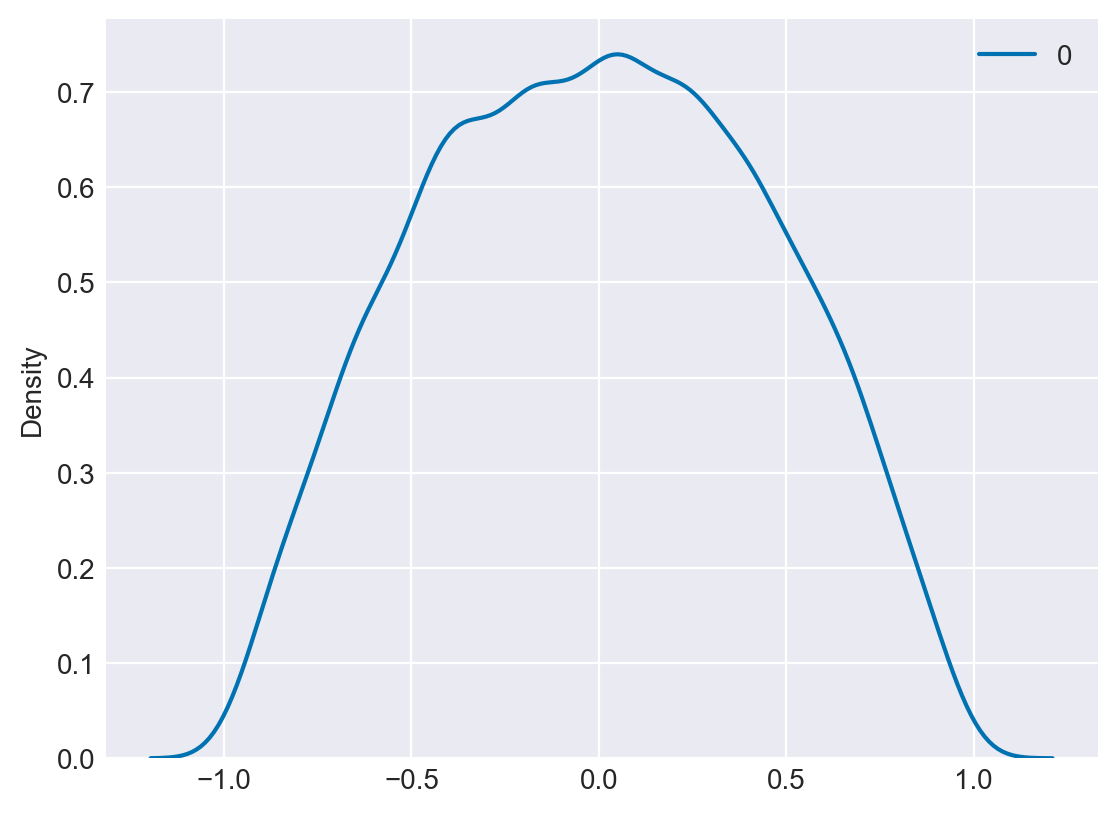

In [104]:
R = pm.draw(pm.LKJCorr.dist(n=2,eta=2,), 10000)

sns.kdeplot(R);

#### Code 14.12

In [ ]:
np.random.seed(867530)
with pm.Model() as m14_1:
    Rho = pm.LKJCorr('Rho', n=2, eta=2)
    
    sigma = pm.Exponential('sigma', 1)

    sigma_cafe = pm.Exponential('sigma_cafe', 1, shape = 2)
    b = pm.Normal('b', -1, .5)
    a = pm.Normal('a', 5, 2)

    # This math wont be neccesary once we start using Cholesky but for now we must.  Just copy paste
    Rho_matrix = pm.math.stack([
        pm.math.stack([1.0, Rho[0]]),
        pm.math.stack([Rho[0], 1.0])
    ])
    cov_ab = sigma_cafe[0] * Rho[0] * sigma_cafe[1] 
    Sigma = pm.math.stack([
        pm.math.stack([sigma_cafe[0]**2, cov_ab]),
        pm.math.stack([cov_ab, sigma_cafe[1]**2])
    ])

    ab_cafe = pm.MvNormal('ab_cafe',
                          mu=pm.math.stack([a, b]),
                          cov=Sigma,
                          shape=(N_cafes, 2))

    #Splitting them out like this will make analysis much easier going forward
    a_cafe = pm.Deterministic('a_cafe', ab_cafe[:,0])
    b_cafe = pm.Deterministic('b_cafe', ab_cafe[:,1])

    mu =  a_cafe[d.cafe] + b_cafe[d.cafe] * d.afternoon
    wait = pm.Normal('wait', mu=mu, sigma=sigma, observed=d.wait)
    trace_m14_1 = pm.sample(cores=1, idata_kwargs={'log_likelihood': True})

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [Rho, sigma, sigma_cafe, b, a, ab_cafe]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 21 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


#### Code 14.13

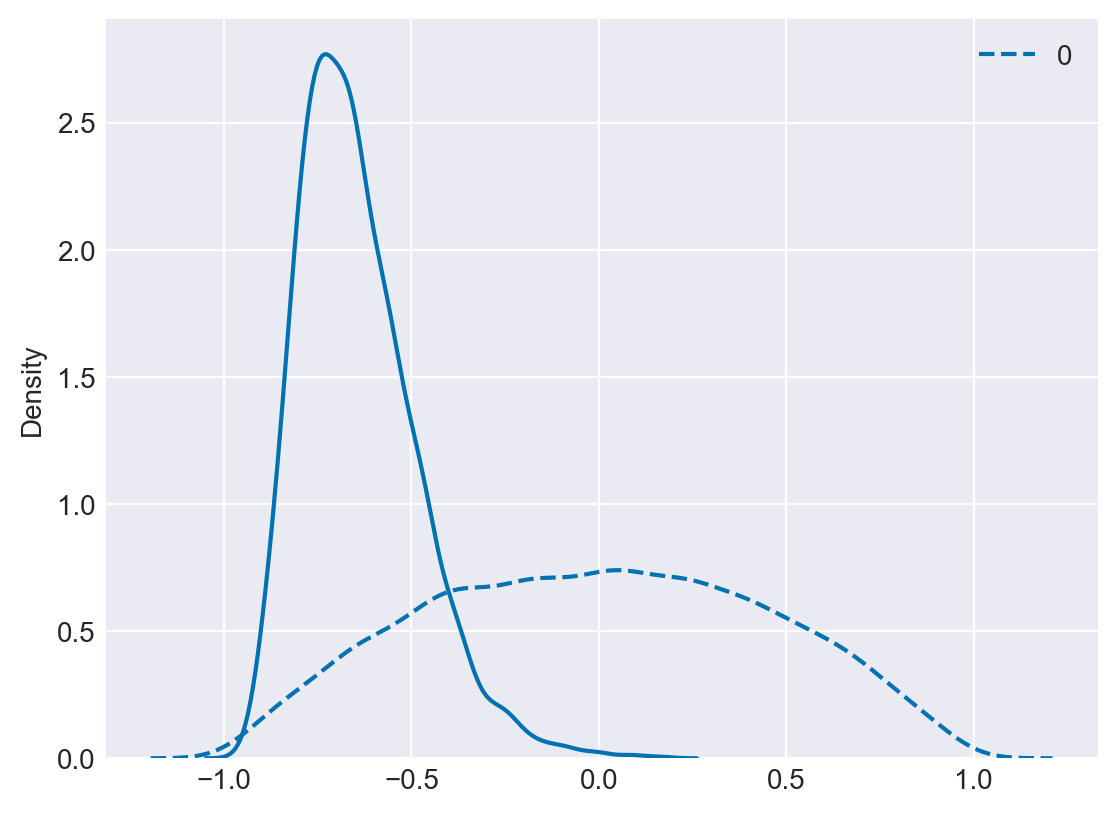

In [106]:
sns.kdeplot(trace_m14_1.posterior.Rho.values.flatten())
#lkj_draws = pm.draw(pm.LKJCorr.dist(n=2,eta=2,), 10000)
sns.kdeplot(R, linestyle = '--', color = 'black');

#### Code 14.14

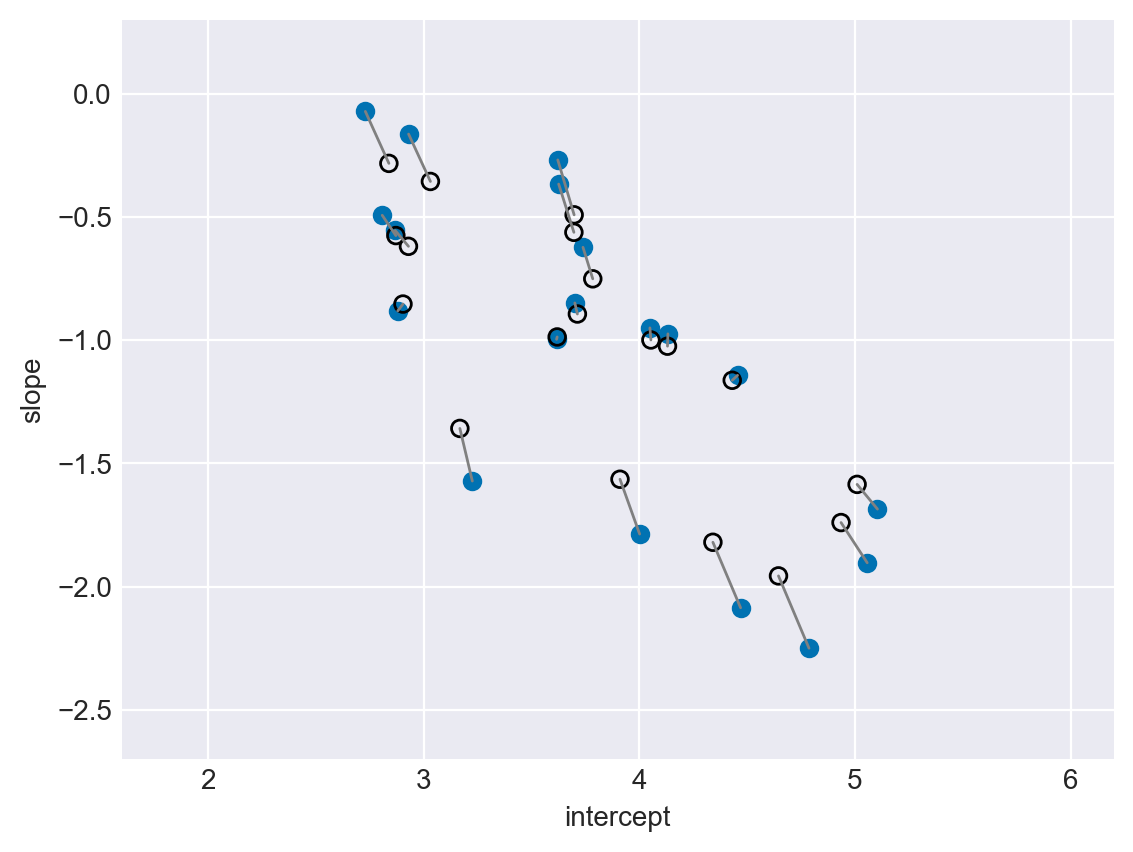

In [141]:
post = trace_m14_1.posterior


# compute unpooled estimates directly from data
a1 = d[(d.afternoon == 0)].groupby('cafe').wait.mean()
b1 = d[(d.afternoon == 1)].groupby('cafe').wait.mean() - a1

# extract posterior means of partially pooled estimates
a2 = post.a_cafe.mean(dim=['chain','draw'])
b2 = post.b_cafe.mean(dim=['chain', 'draw'])

#plot both and connect with lines
fig, ax = plt.subplots()
ax.scatter(a1, b1, label='Unpooled')
ax.scatter(a2, b2, facecolor='none', edgecolor='black', label='Partially pooled')
for i in range(len(a1)):
    ax.plot([a1.iloc[i], a2[i]], [b1.iloc[i], b2[i]], color='gray', linestyle='-', linewidth=1)
ax.set_xlabel('intercept')
ax.set_xlim(1.6,6.2)
ax.set_xticks([2,3,4,5,6])

ax.set_ylabel('slope')
ax.set_ylim(-2.7, .3)
ax.set_yticks([-2.5,-2,-1.5,-1,-.5,0]);

#### Code 14.15

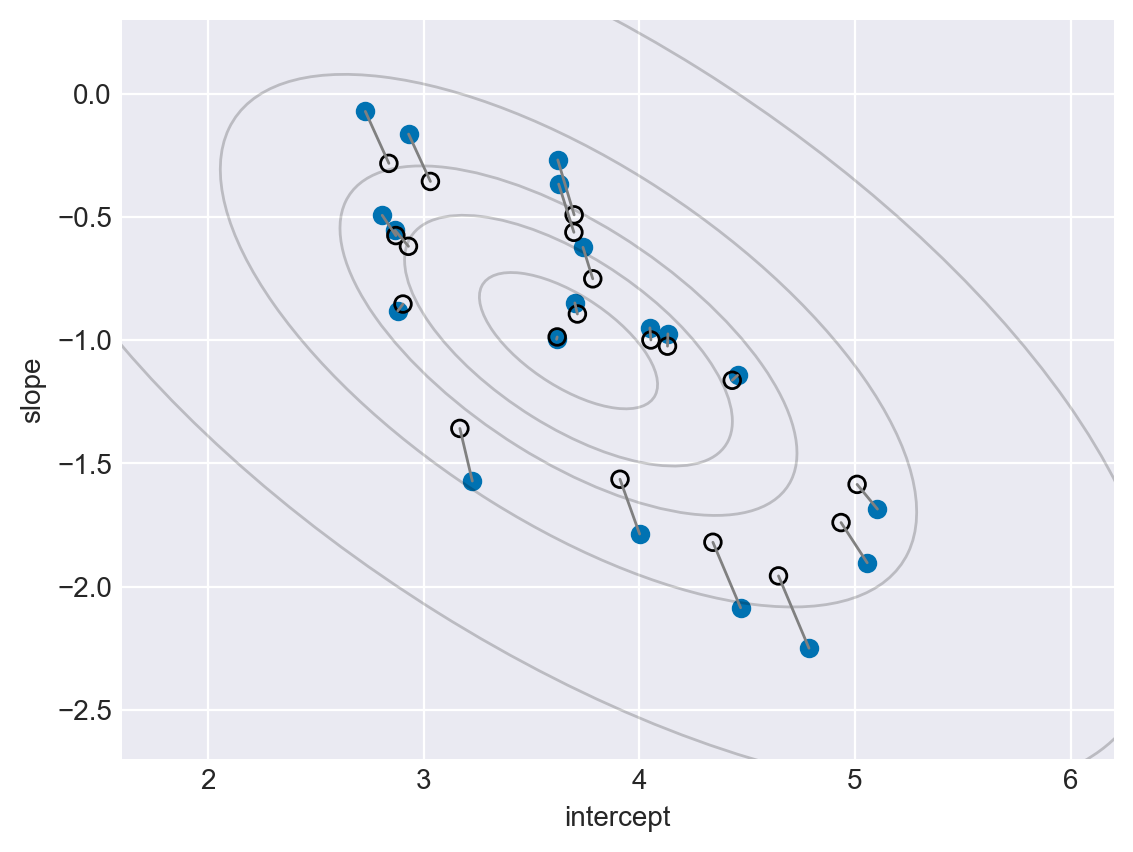

In [142]:
Mu_est = [float(post.a.mean(dim=['chain','draw']).values), float(post.b.mean(dim=['chain','draw']).values)]
rho_est =float(post.Rho.mean(dim=['chain','draw']).values)
sa_est = float(post.sigma_cafe.sel(sigma_cafe_dim_0=0).mean(dim=['chain','draw']).values)
sb_est = float(post.sigma_cafe.sel(sigma_cafe_dim_0=1).mean(dim=['chain','draw']).values)


cov_ab = sa_est * sb_est * rho_est

Sigma_est = np.array([[sa_est**2, cov_ab],
                      [cov_ab, sb_est**2]])

 
# R's ellipses package computes teh rotation/eigenvalues but pyplots doesnt so we need to do that here
eigenvalues, eigenvectors = np.linalg.eig(Sigma_est)
angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))

for l in [0.1, 0.3, 0.5, 0.8, .99]:
    scale = np.sqrt(chi2.ppf(l, df=2))
    width = 2 * scale * np.sqrt(eigenvalues[0])
    height = 2 * scale * np.sqrt(eigenvalues[1])
    
    ellipse = Ellipse(Mu_est, width, height, 
                      angle=angle,  # <-- This is the key!
                      edgecolor='black', facecolor='none', alpha=0.2)
    ax.add_patch(ellipse)
fig

#### Code 14.16

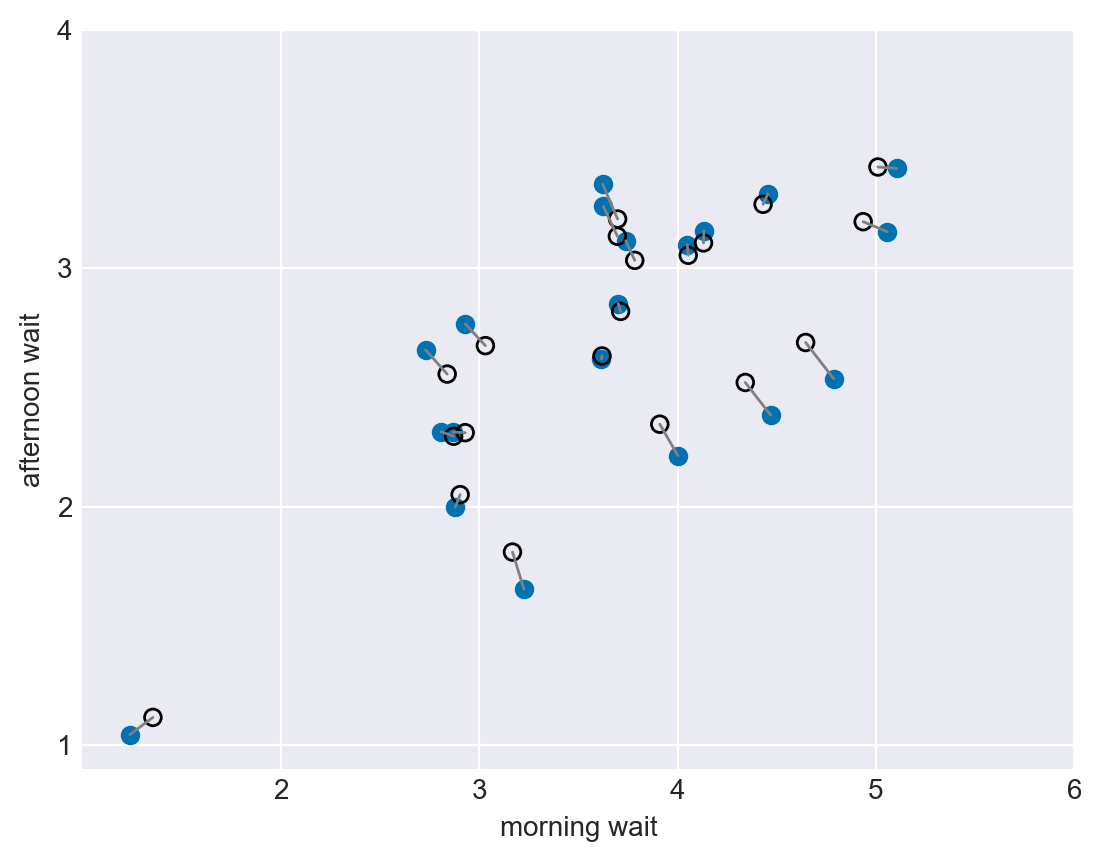

In [173]:
wait_morning_1 = a1.values
wait_afternoon_1 = a1.values + b1.values
wait_morning_2 = a2.values
wait_afternoon_2 = a2.values+b2.values

fig, ax = plt.subplots()
ax.scatter(wait_morning_1, wait_afternoon_1, label='Unpooled')
ax.scatter(wait_morning_2, wait_afternoon_2, facecolor='none', edgecolor='black', label='Partially pooled')
for i in range(len(wait_morning_1)):
    ax.plot([wait_morning_1[i], wait_morning_2[i]], [wait_afternoon_1[i], wait_afternoon_2[i]], color='gray', linestyle='-', linewidth=1)
ax.set_xlabel('morning wait')
ax.set_xlim(1,6)
ax.set_xticks([2,3,4,5,6])

ax.set_ylabel('afternoon wait')
ax.set_ylim(.9, 4)
ax.set_yticks([1,2,3,4]);

#### Code 14.17

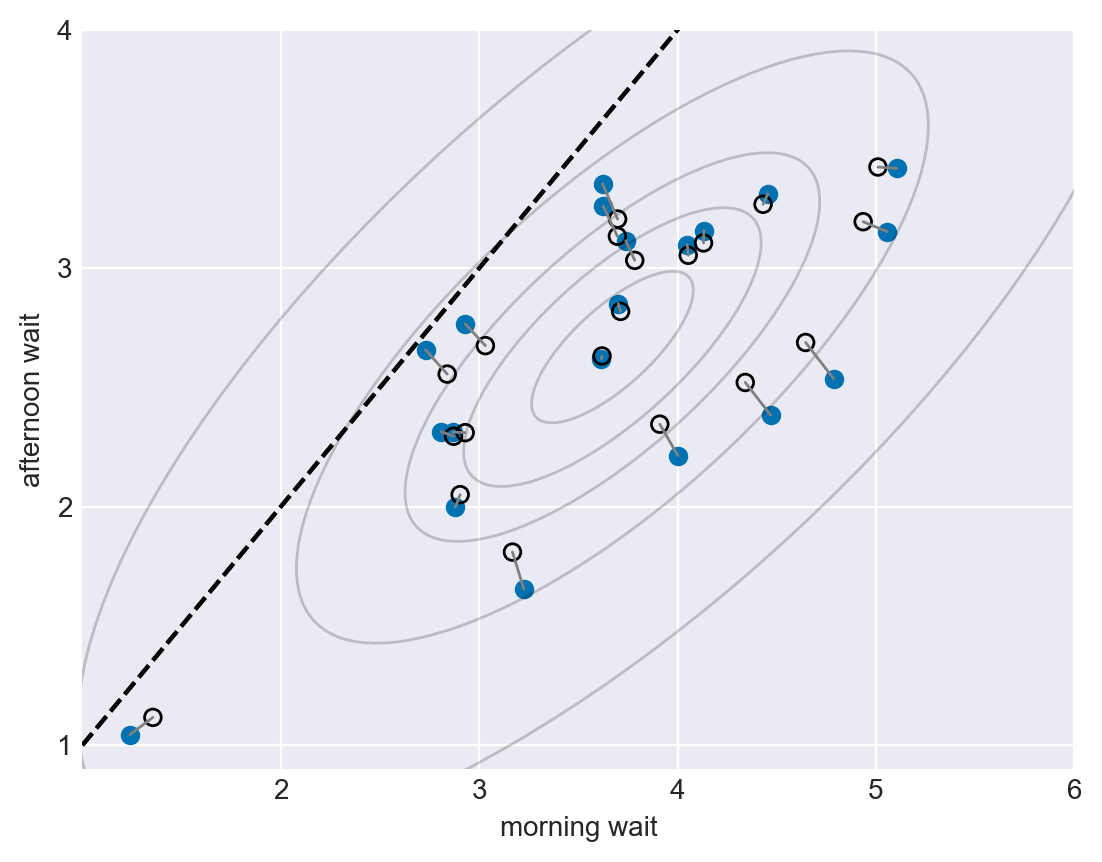

In [174]:
## We have to reset the a_mean and b_mean values
a_mean = float(post.a.mean(dim=['chain','draw']).values)
b_mean = float(post.b.mean(dim=['chain','draw']).values)

v = np.random.multivariate_normal(Mu_est, Sigma_est, 1000)
v_1 = v[:,0]
v_2 = v[:,0] + v[:,1]
Sigma_est2 = np.cov(np.column_stack([v_1,v_2]), rowvar=False)

Mu_est = [a_mean, b_mean]  # Fresh values
Mu_est2 = [float(Mu_est[0]), float(Mu_est[0]) + float(Mu_est[1])]
 
# R's ellipses package computes teh rotation/eigenvalues but pyplots doesnt so we need to do that here
eigenvalues, eigenvectors = np.linalg.eig(Sigma_est2.astype(float))
angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))

for l in [0.1, 0.3, 0.5, 0.8, .99]:
    scale = np.sqrt(chi2.ppf(l, df=2))
    width = 2 * scale * np.sqrt(eigenvalues[0])
    height = 2 * scale * np.sqrt(eigenvalues[1])
    
    ellipse = Ellipse(Mu_est2, width, height, 
                      angle=angle,  
                      edgecolor='black', facecolor='none', alpha=0.2)
    ax.add_patch(ellipse)
    
    # Create the dashed line for afternoon wait = morning wait
    x_min, x_max = ax.get_xlim()
    ax.plot([x_min, x_max], [x_min, x_max], 'k--', alpha=0.5)

fig

#### Code 14.18

In [326]:
d = pd.read_csv('data/chimpanzees.csv', sep=';')
d['block_id'] = d.block 
d['treatment'] = d.prosoc_left + 2 * d.condition 

dat = pd.DataFrame({
       'L': d.pulled_left,
       'tid': d.treatment,
       'actor': d.actor-1,
       'block_id': d.block_id -1
       })

np.random.seed(4387510)

with pm.Model() as m14_2:
    # Fixed priors
    g = pm.Normal('g', 0, 1, shape=4)  # 4 treatments
    
    sigma_actor = pm.Exponential('sigma_actor', 1, shape=4)
    Rho_actor_packed = pm.LKJCorr('Rho_actor', n=4, eta=4)  # Returns 6 values
    
    Rho_actor = pm.math.stack([
        pm.math.stack([1.0,                   Rho_actor_packed[0], Rho_actor_packed[1], Rho_actor_packed[3]]),
        pm.math.stack([Rho_actor_packed[0],   1.0,                 Rho_actor_packed[2], Rho_actor_packed[4]]),
        pm.math.stack([Rho_actor_packed[1],   Rho_actor_packed[2], 1.0,                 Rho_actor_packed[5]]),
        pm.math.stack([Rho_actor_packed[3],   Rho_actor_packed[4], Rho_actor_packed[5], 1.0                ])
    ])
    
    s = sigma_actor 
    Sigma_actor = pm.math.stack([
        pm.math.stack([s[0]*s[0]*1.0,                   s[0]*s[1]*Rho_actor_packed[0], s[0]*s[2]*Rho_actor_packed[1], s[0]*s[3]*Rho_actor_packed[3]]),
        pm.math.stack([s[1]*s[0]*Rho_actor_packed[0],   s[1]*s[1]*1.0,                 s[1]*s[2]*Rho_actor_packed[2], s[1]*s[3]*Rho_actor_packed[4]]),
        pm.math.stack([s[2]*s[0]*Rho_actor_packed[1],   s[2]*s[1]*Rho_actor_packed[2], s[2]*s[2]*1.0,                 s[2]*s[3]*Rho_actor_packed[5]]),
        pm.math.stack([s[3]*s[0]*Rho_actor_packed[3],   s[3]*s[1]*Rho_actor_packed[4], s[3]*s[2]*Rho_actor_packed[5], s[3]*s[3]*1.0                ])
    ])
    
    sigma_block = pm.Exponential('sigma_block', 1, shape=4)
    Rho_block_packed = pm.LKJCorr('Rho_block', n=4, eta=4)
    
    Rho_block = pm.math.stack([
        pm.math.stack([1.0,                   Rho_block_packed[0], Rho_block_packed[1], Rho_block_packed[3]]),
        pm.math.stack([Rho_block_packed[0],   1.0,                 Rho_block_packed[2], Rho_block_packed[4]]),
        pm.math.stack([Rho_block_packed[1],   Rho_block_packed[2], 1.0,                 Rho_block_packed[5]]),
        pm.math.stack([Rho_block_packed[3],   Rho_block_packed[4], Rho_block_packed[5], 1.0                ])
    ])
    
    s = sigma_block
    Sigma_block = pm.math.stack([
        pm.math.stack([s[0]*s[0]*1.0,                   s[0]*s[1]*Rho_block_packed[0], s[0]*s[2]*Rho_block_packed[1], s[0]*s[3]*Rho_block_packed[3]]),
        pm.math.stack([s[1]*s[0]*Rho_block_packed[0],   s[1]*s[1]*1.0,                 s[1]*s[2]*Rho_block_packed[2], s[1]*s[3]*Rho_block_packed[4]]),
        pm.math.stack([s[2]*s[0]*Rho_block_packed[1],   s[2]*s[1]*Rho_block_packed[2], s[2]*s[2]*1.0,                 s[2]*s[3]*Rho_block_packed[5]]),
        pm.math.stack([s[3]*s[0]*Rho_block_packed[3],   s[3]*s[1]*Rho_block_packed[4], s[3]*s[2]*Rho_block_packed[5], s[3]*s[3]*1.0                ])
    ])
    
    n_actors = len(dat.actor.unique())
    n_blocks = len(dat.block_id.unique())
    
    alpha = pm.MvNormal('alpha', mu=np.zeros(4), cov=Sigma_actor, shape=(n_actors, 4))
    beta = pm.MvNormal('beta', mu=np.zeros(4), cov=Sigma_block, shape=(n_blocks, 4))
    
    p = pm.math.sigmoid(g[dat.tid] + alpha[dat.actor, dat.tid] + beta[dat.block_id, dat.tid])
    
    L = pm.Bernoulli('L', p=p, observed=dat.L)
    
    trace_m14_2 = pm.sample(cores=1, idata_kwargs={'log_likelihood': True})

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [g, sigma_actor, Rho_actor, sigma_block, Rho_block, alpha, beta]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 184 seconds.
There were 516 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


#### Code 14.13

In [302]:
with pm.Model() as m14_3:
    g = pm.Normal('g', 0, 1, shape=4)
    
    n_actors = len(dat.actor.unique())
    n_blocks = len(dat.block_id.unique())
    
    chol_actor, corr_actor, sigma_actor = pm.LKJCholeskyCov(
        'chol_actor', eta=2, n=4,
        sd_dist=pm.Exponential.dist(1, shape=4)
    )
    
    z_actor = pm.Normal('z_actor', 0, 1, shape=(n_actors, 4))
    alpha = pm.Deterministic('alpha', pm.math.dot(z_actor, chol_actor.T))
    
    chol_block, corr_block, sigma_block = pm.LKJCholeskyCov(
        'chol_block', eta=2, n=4,
        sd_dist=pm.Exponential.dist(1, shape=4)
    )
    
    z_block = pm.Normal('z_block', 0, 1, shape=(n_blocks, 4))
    beta = pm.Deterministic('beta', pm.math.dot(z_block, chol_block.T))
    
    p = pm.math.sigmoid(g[dat.tid] + alpha[dat.actor, dat.tid] + beta[dat.block_id, dat.tid])
    
    L = pm.Bernoulli('L', p=p, observed=dat.L)
    
    trace_m14_3 = pm.sample(cores=1, idata_kwargs={'log_likelihood': True})

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [g, chol_actor, z_actor, chol_block, z_block]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 36 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


#### Code 14.20

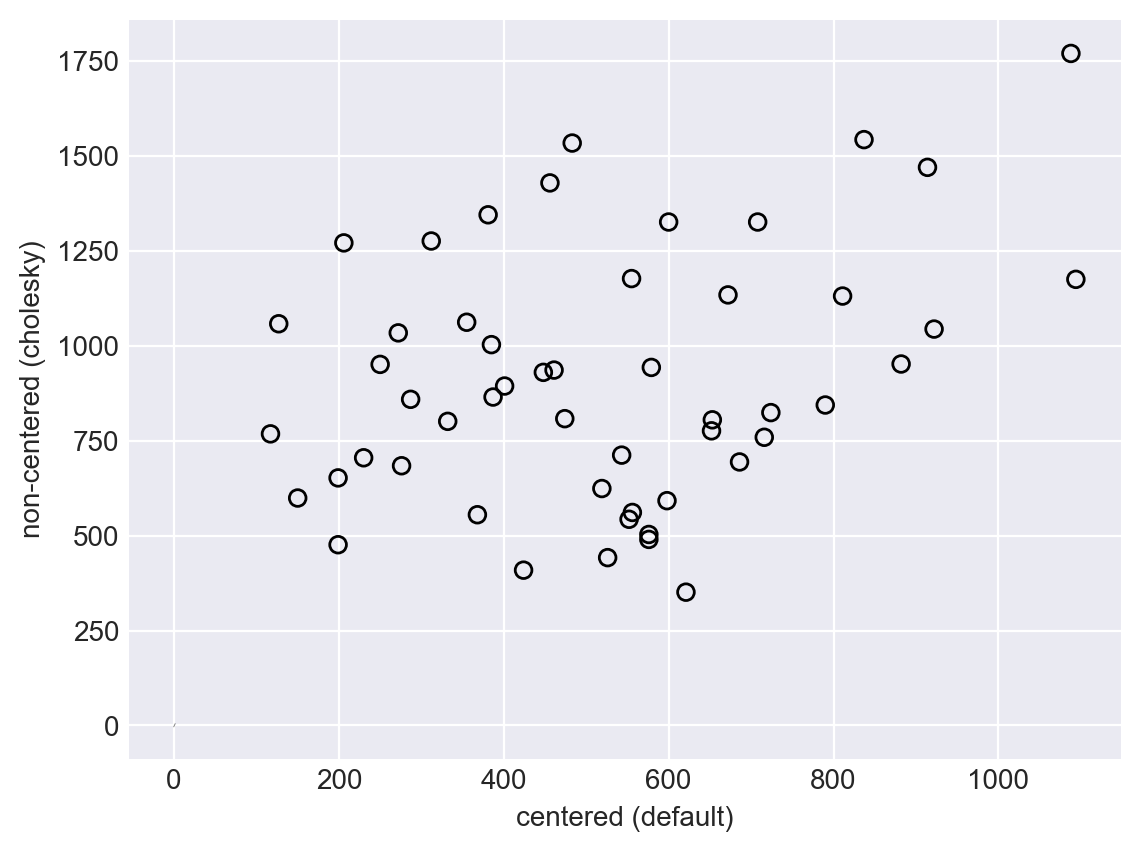

In [203]:
neff_nc = pm.summary(trace_m14_3, var_names = ['alpha', 'beta'])['ess_bulk'].values
neff_c = pm.summary(trace_m14_2, var_names = ['alpha', 'beta'])['ess_bulk'].values

plt.scatter(neff_c, neff_nc, facecolor = 'none', edgecolor='black')
plt.ylabel('non-centered (cholesky)')
plt.xlabel('centered (default)')
x_min, x_max = ax.get_xlim()
plt.plot([0, 1], [1, 0], 'k--', alpha=0.5)

#### Code 14.21

In [227]:
pm.summary(trace_m14_3, var_names = ['chol_actor_stds', 'chol_block_stds'])


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
chol_actor_stds[0],1.414,0.512,0.630,2.353,0.026,0.019,452.0,251.0,1.00
chol_actor_stds[1],0.916,0.398,0.280,1.642,0.013,0.010,899.0,952.0,1.01
chol_actor_stds[2],1.859,0.558,0.952,2.935,0.021,0.015,736.0,1052.0,1.01
chol_actor_stds[3],1.579,0.634,0.549,2.652,0.034,0.024,394.0,393.0,1.01
chol_block_stds[0],0.426,0.319,0.001,0.988,0.013,0.009,433.0,351.0,1.00
chol_block_stds[1],0.436,0.338,0.011,1.031,0.015,0.010,246.0,122.0,1.00
chol_block_stds[2],0.311,0.293,0.013,0.837,0.020,0.014,203.0,218.0,1.01
chol_block_stds[3],0.469,0.347,0.021,1.063,0.020,0.014,254.0,368.0,1.01


#### Code 14.22

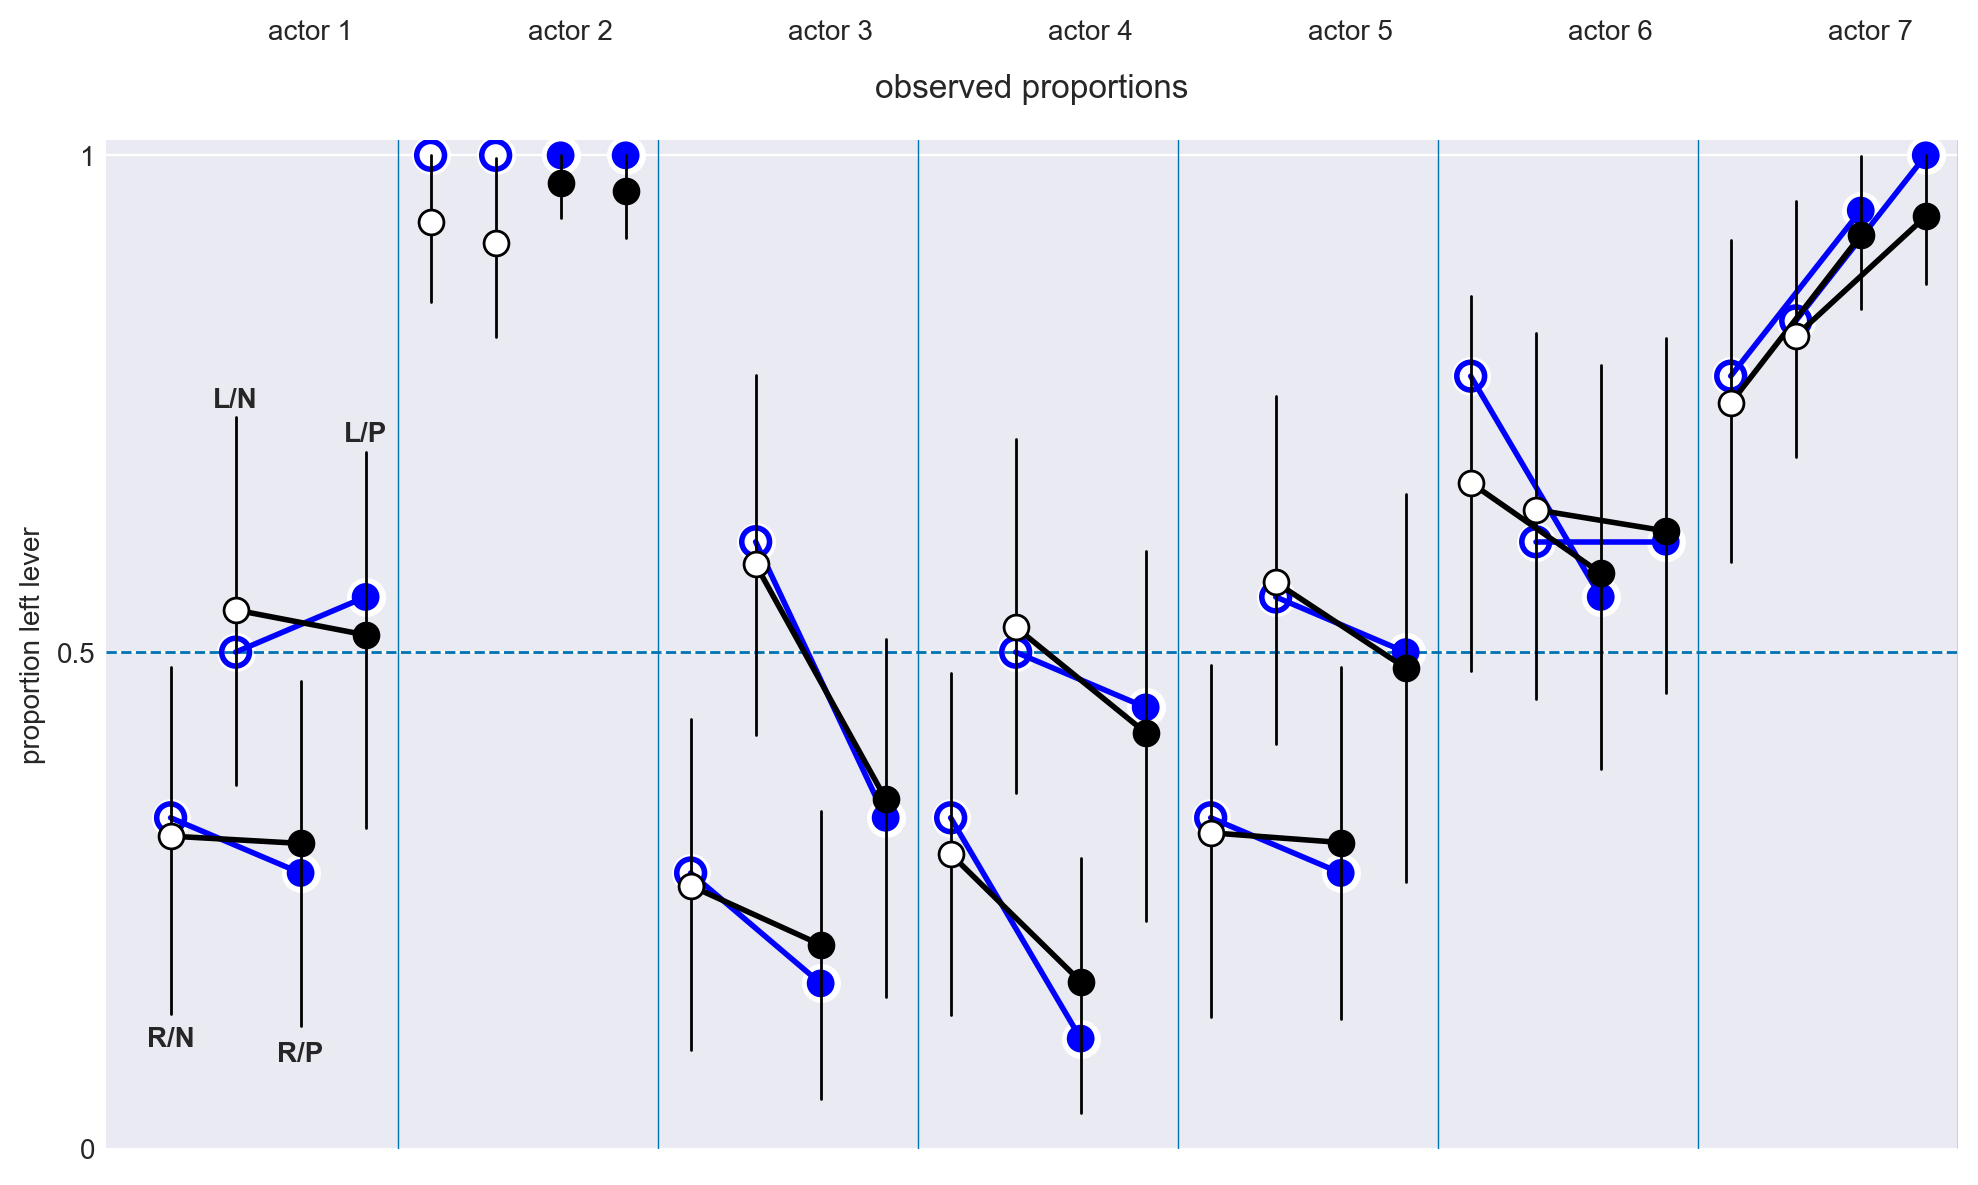

In [269]:
#compute generate posterior prections
actor_idx = np.repeat(np.arange(7), 4) 
tid_idx = np.tile(np.arange(4), 7)       
block_idx = np.full(28, 4)               

post = trace_m14_3.posterior

g_samples = post['g'].values           
alpha_samples = post['alpha'].values   
beta_samples = post['beta'].values     #

n_chains, n_draws = g_samples.shape[:2]
n_samples = n_chains * n_draws

g_flat = g_samples.reshape(n_samples, 4)
alpha_flat = alpha_samples.reshape(n_samples, 7, 4)  
beta_flat = beta_samples.reshape(n_samples, 6, 4)    

logit_p = inv_logit((g_flat[:, tid_idx] + 
           alpha_flat[:, actor_idx, tid_idx] + 
           beta_flat[:, block_idx, tid_idx]))

p_mu = p.mean(axis=0)                    
p_ci = az.hdi(p, hdi_prob=0.89)        

#set up plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(0, 28.5)
ax.set_ylim(0, 1.015)
ax.set_xlabel("")
ax.set_ylabel("proportion left lever")
ax.set_xticks([])
ax.set_yticks([])
ax.set_yticks([0, 0.5, 1])
ax.set_yticklabels([0, 0.5, 1])
ax.set_title("observed proportions\n", ha='center', va='center', fontsize=12)


ax.axhline(y=0.5, linestyle='--', linewidth=1)

for j in range(7):
    ax.axvline(x=(j)*4+4.5, linewidth=0.5)

for j in range(7):
    ax.text((j)*4+2.5, 1.1, f"actor {j+1}", transform=ax.get_xaxis_transform())


# compute mean for each actor in each treatment
pl = d.groupby(['actor', 'treatment'])['pulled_left'].mean()
pl_array = pl.unstack().values  

xo = 1 # offset distance to stagger raw data and predictions

# raw data
for j in [1, 3, 4, 5, 6, 7]:
    ax.plot([(j-1)*4+1, (j-1)*4+3], [pl_array[j-1, 0], pl_array[j-1, 2]], 
            linewidth=2, color='blue')
    ax.plot([(j-1)*4+2, (j-1)*4+4], [pl_array[j-1, 1], pl_array[j-1, 3]], 
            linewidth=2, color='blue')

y_vals = pl_array.flatten()
ax.scatter(range(1, 29), y_vals, marker='o', color='white', s=170, zorder=1)

x_vals = np.arange(1, 29)
for i, (x, y) in enumerate(zip(x_vals, y_vals)):
    if i % 4 in [0, 1]:
        ax.scatter(x, y, marker='o', color='blue', s=100, 
                  facecolors='none', edgecolors='blue', linewidths=2, zorder=2)
    else:
        ax.scatter(x, y, marker='o', color='blue', edgecolor = 'none',s=100, zorder=2)

# plot posteriors
for j in [0, 2, 3, 4, 5, 6]:  
    x_vals = [j*4 + 0 + xo, j*4 + 2 + xo]
    y_vals = [p_mu[j*4 + 0], p_mu[j*4 + 2]]
    ax.plot(x_vals, y_vals, 'k-', lw=2)
    
    x_vals = [j*4 + 1 + xo, j*4 + 3 + xo]
    y_vals = [p_mu[j*4 + 1], p_mu[j*4 + 3]]
    ax.plot(x_vals, y_vals, 'k-', lw=2)

for i in range(28):
    ax.plot([i + xo, i + xo], [p_ci[i, 0], p_ci[i, 1]], 'k-', lw=1)

# White points (treatments 0, 1 within each actor)
white_idx = [i for i in range(28) if i % 4 < 2]
ax.scatter(np.array(white_idx) + xo, p_mu[white_idx], 
           edgecolor='black', facecolor='white', s=80, zorder=3)

# Black points (treatments 2, 3 within each actor)
black_idx = [i for i in range(28) if i % 4 >= 2]
ax.scatter(np.array(black_idx) + xo, p_mu[black_idx], 
           edgecolor='black', facecolor='black', s=80, zorder=3)


yoff = 0.2
ax.text(1, pl_array[0, 0]-.21, "R/N", ha='center', va='top', fontsize=10, fontweight='bold')
ax.text(2, pl_array[0, 1]+.24, "L/N", ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.text(3, pl_array[0, 2]-.17, "R/P", ha='center', va='top', fontsize=10, fontweight='bold')
ax.text(4, pl_array[0, 3]+.15, "L/P", ha='center', va='bottom', fontsize=10,fontweight='bold')
plt.tight_layout()
plt.show()

#### Code 14.23

In [327]:
np.random.seed(73)
N = 500
U_sim = np.random.normal(0,1,N)
Q_sim = np.random.choice(range(1,5), size = N, replace = True)
E_sim = np.random.normal(U_sim + Q_sim, size = N)
W_sim = np.random.normal(U_sim + 0 * E_sim, size = N)



dat_sim_df = pd.DataFrame({
    'W':( W_sim - W_sim.mean()) / W_sim.std(),
    'E': ( E_sim - E_sim.mean()) / E_sim.std(),
    'Q': ( Q_sim - Q_sim.mean()) / Q_sim.std()
})


#### Code 14.24

In [334]:
with pm.Model() as m14_4:
    COLS = ['E','Q','W'] # This is for later
    dat_sim = pm.Data('dat_sim', dat_sim_df[COLS].values) #This is for later

    E = dat_sim[:,0]
    Q = dat_sim[:,1]
    W = dat_sim[:,2]

    sigma = pm.Exponential('sigma', 1)
    bEW = pm.Normal('bEW', 0, .5)
    aW = pm.Normal('aW', 0, .2)
    mu = pm.Deterministic('mu', aW + bEW* E)
    W = pm.Normal('W', mu = mu, sigma = sigma, observed = W)
    trace_m14_4 = pm.sample(cores = 1, idata_kwargs={'log_likelihood': True})

pm.summary(trace_m14_4, var_names =['aW','bEW','sigma'])

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [sigma, bEW, aW]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 2 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
aW,0.000,0.041,-0.079,0.076,0.001,0.001,2909.0,1411.0,1.0
bEW,0.383,0.041,0.307,0.460,0.001,0.001,3109.0,1638.0,1.0
sigma,0.926,0.029,0.874,0.982,0.001,0.000,2898.0,1570.0,1.0


#### Code 14.25

In [ ]:
with pm.Model() as m14_5:
    sigma = pm.Exponential('sigma', 1)
    aW = pm.Normal('aW', 0, .2)
    bEW = pm.Normal('bEW', 0, .5)
    bQW = pm.Normal('bQW', 0, .5)
    mu = pm.Deterministic('mu', aW + bEW* dat_sim_df.E + bQW * dat_sim_df.Q)
    W = pm.Normal('W', mu = mu, sigma = sigma, observed = dat_sim_df.W)
    trace_m14_5 = pm.sample(cores = 1, idata_kwargs={'log_likelihood': True})

pm.summary(trace_m14_5, var_names =['aW','bEW', 'bQW','sigma'])

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [sigma, aW, bEW, bQW]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 2 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
aW,-0.000,0.038,-0.071,0.070,0.001,0.001,2043.0,1617.0,1.0
bEW,0.668,0.053,0.571,0.767,0.001,0.001,1642.0,1639.0,1.0
bQW,-0.418,0.053,-0.519,-0.322,0.001,0.001,1632.0,1581.0,1.0
sigma,0.871,0.028,0.824,0.925,0.001,0.000,1780.0,1461.0,1.0


#### Code 14.26

In [ ]:
with pm.Model() as m14_6:
    COLS = ['E','Q','W'] # This is for later
    dat_sim = pm.Data('dat_sim', dat_sim_df[COLS].values) #This is for later

    E = dat_sim[:,0]
    Q = dat_sim[:,1]
    W = dat_sim[:,2]

    Sigma = pm.Exponential.dist(1, shape = 2)
    Rho, _, _ = pm.LKJCholeskyCov('Rho', 
                eta = 2, 
                n = 2,
                sd_dist = Sigma)

    c_aW_aE = pm.Normal('c_aW_aE', 0, .2, shape = 2)
    c_bEW_bQE = pm.Normal('c_bEW_bQE', 0, .5, shape = 2)

    mu_W = pm.Deterministic('mUW', c_aW_aE[0] + c_bEW_bQE[0] * E)
    mu_E = pm.Deterministic('mUE', c_aW_aE[1] + c_bEW_bQE[1] * Q)

    obs = pm.math.concatenate([dat_sim[:, 2:3], dat_sim[:, 0:1]], axis=1)

    c_WE = pm.MvNormal('c_WE', mu = pm.math.stack([mu_W, mu_E], axis = 1), chol = Rho, observed = obs)


    trace_m14_6 = pm.sample(cores = 1, idata_kwargs={'log_likelihood': True})

pm.summary(trace_m14_6, var_names = ['c_aW_aE' ,'c_bEW_bQE', 'Rho_corr', 'Rho_stds'])
    

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [Rho, c_aW_aE, c_bEW_bQE]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 12 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
c_aW_aE[0],-0.000,0.044,-0.084,0.081,0.001,0.001,1671.0,1462.0,1.0
c_aW_aE[1],-0.000,0.032,-0.060,0.060,0.001,0.001,1734.0,1218.0,1.0
c_bEW_bQE[0],0.051,0.064,-0.068,0.169,0.002,0.001,1159.0,1284.0,1.0
c_bEW_bQE[1],0.680,0.033,0.623,0.750,0.001,0.001,1484.0,1208.0,1.0
"Rho_corr[0, 0]",1.000,0.000,1.000,1.000,0.000,0.000,2000.0,2000.0,NaN
"Rho_corr[0, 1]",0.461,0.051,0.368,0.554,0.001,0.001,1191.0,1346.0,1.0
"Rho_corr[1, 0]",0.461,0.051,0.368,0.554,0.001,0.001,1191.0,1346.0,1.0
"Rho_corr[1, 1]",1.000,0.000,1.000,1.000,0.000,0.000,1911.0,2000.0,1.0
Rho_stds[0],0.986,0.038,0.920,1.066,0.001,0.001,1563.0,1609.0,1.0
Rho_stds[1],0.733,0.024,0.691,0.782,0.001,0.000,2245.0,1341.0,1.0


#### Code 14.27

In [335]:
with m14_4:
    pm.set_data({'dat_sim': dat_sim_df[COLS]})
    trace_m14_4x = pm.sample(cores = 1, idata_kwargs={'log_likelihood': True}) # This is what were after

with m14_6:
    pm.set_data({'dat_sim': dat_sim_df[COLS]})
    trace_m14_6x = pm.sample(cores = 1, idata_kwargs={'log_likelihood': True})


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [sigma, bEW, aW]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [Rho, c_aW_aE, c_bEW_bQE]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 12 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


#### Code 14.28

In [336]:
np.random.seed(73)
N = 500
U_sim = np.random.normal(0,1,N)
Q_sim = np.random.choice(range(1,5), size = N, replace = True)
E_sim = np.random.normal(U_sim + Q_sim, size = N)
W_sim = np.random.normal(-U_sim + .2 * E_sim, size = N)



dat_sim_df = pd.DataFrame({
    'W':( W_sim - W_sim.mean()) / W_sim.std(),
    'E': ( E_sim - E_sim.mean()) / E_sim.std(),
    'Q': ( Q_sim - Q_sim.mean()) / Q_sim.std()
})


#### Code 14.29

_The CausalGraphicalModels package we've been using does not have an instrumental variables functionality so we'll skip this._

#### Code 14.30

In [353]:
d = pd.read_csv('data/KosterLeckie.csv')


#### Code 14.31

In [379]:
N = d.shape[0] 
N_households = max(d.hidB) 
did = d.did - 1
hidA = d.hidA -1
hidB = d.hidB -1
giftsAB = d.giftsAB 
giftsBA = d.giftsBA 


with pm.Model() as m14_7:
    ## dyad effects
    sigma_d = pm.Exponential.dist(1, shape = 2)
    z = pm.Normal('z', 0,1, shape = (N,2))
    chol_, _, _ = pm.LKJCholeskyCov('Rho',
                                        eta = 8,
                                        n = 2,
                                        sd_dist = sigma_d)
    d_ = pm.Deterministic('d', pm.math.dot(z, chol_.T))

    #gr effects
    sigma_gr = pm.Exponential.dist(1, shape= 2)
    Rho_gr,_,sigma_gr_ = pm.LKJCholeskyCov('Rho_gr', 
                                eta = 4,
                                n = 2,
                                sd_dist = sigma_gr)
    gr = pm.MvNormal('gr', mu = pm.math.zeros(2), chol = Rho_gr, shape = (N_households, 2))

    # linear model
    a = pm.Normal('a', 0,1)
    log_lambdaAB = pm.Deterministic('log_lambdaAB', pm.math.exp(a + gr[hidA, 0] + gr[hidB, 1] + d_[did,0]))
    log_lambdaBA = pm.Deterministic('log_lambdaBA', pm.math.exp(a + gr[hidB, 0] + gr[hidA, 1] + d_[did,1]))

    giftsAB = pm.Poisson('giftsAB', log_lambdaAB, observed = giftsAB)
    giftsBA = pm.Poisson('giftsBA', log_lambdaBA, observed = giftsBA)

    trace_m14_7 = pm.sample(cores = 1, idata_kwargs={'log_likelihood':True})


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [z, Rho, Rho_gr, gr, a]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 81 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


#### Code 14.32

In [378]:
pm.summary(trace_m14_7, var_names =['Rho_gr_corr','Rho_gr_stds'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"Rho_gr_corr[0, 0]",1.000,0.000,1.000,1.000,0.000,0.000,2000.0,2000.0,NaN
"Rho_gr_corr[0, 1]",-0.402,0.198,-0.761,-0.024,0.008,0.006,654.0,902.0,1.00
"Rho_gr_corr[1, 0]",-0.402,0.198,-0.761,-0.024,0.008,0.006,654.0,902.0,1.00
"Rho_gr_corr[1, 1]",1.000,0.000,1.000,1.000,0.000,0.000,1898.0,1949.0,1.00
Rho_gr_stds[0],0.838,0.137,0.617,1.116,0.004,0.003,978.0,1098.0,1.00
Rho_gr_stds[1],0.414,0.087,0.247,0.572,0.004,0.003,423.0,803.0,1.01


#### Code 14.33

In [445]:
post = trace_m14_7.posterior

g = []
r = []
for i in range(25):
    g.append((post.a.values + post.gr.sel(gr_dim_0 = i, gr_dim_1 = 0)).values) 
    r.append((post.a.values + post.gr.sel(gr_dim_0 = i, gr_dim_1 = 1)).values)

Eg_mu = np.exp(g).mean(axis = (1,2))
Er_mu = np.exp(r).mean(axis = (1,2))

display(Eg_mu, Er_mu)


print(np.array(g).shape)


array([1.11420529, 2.17891541, 5.31881315, 0.86465701, 1.09696021,
       0.65722923, 1.00372587, 0.85786282, 2.38580027, 6.95657126,
       0.71550402, 0.88052584, 4.66078681, 2.09696959, 0.82783025,
       1.7331251 , 2.98082216, 1.34431708, 1.89994633, 4.3200218 ,
       7.08868363, 2.22724476, 5.47550136, 1.36408265, 0.61525698])

array([2.14489353, 1.57257537, 1.28060437, 2.41618369, 2.55247544,
       3.07019055, 2.04655146, 2.28800526, 1.41916588, 1.1867488 ,
       2.58223032, 1.68777739, 1.39608215, 2.20680742, 3.23458874,
       2.76730384, 2.09297926, 1.02905386, 1.82040804, 1.20249833,
       1.26794728, 1.33274676, 1.0516449 , 1.52501833, 2.17572914])

(25, 2, 1000)


#### Code 14.34

In [437]:
print(np.array(g).shape)

(25, 2, 1000)


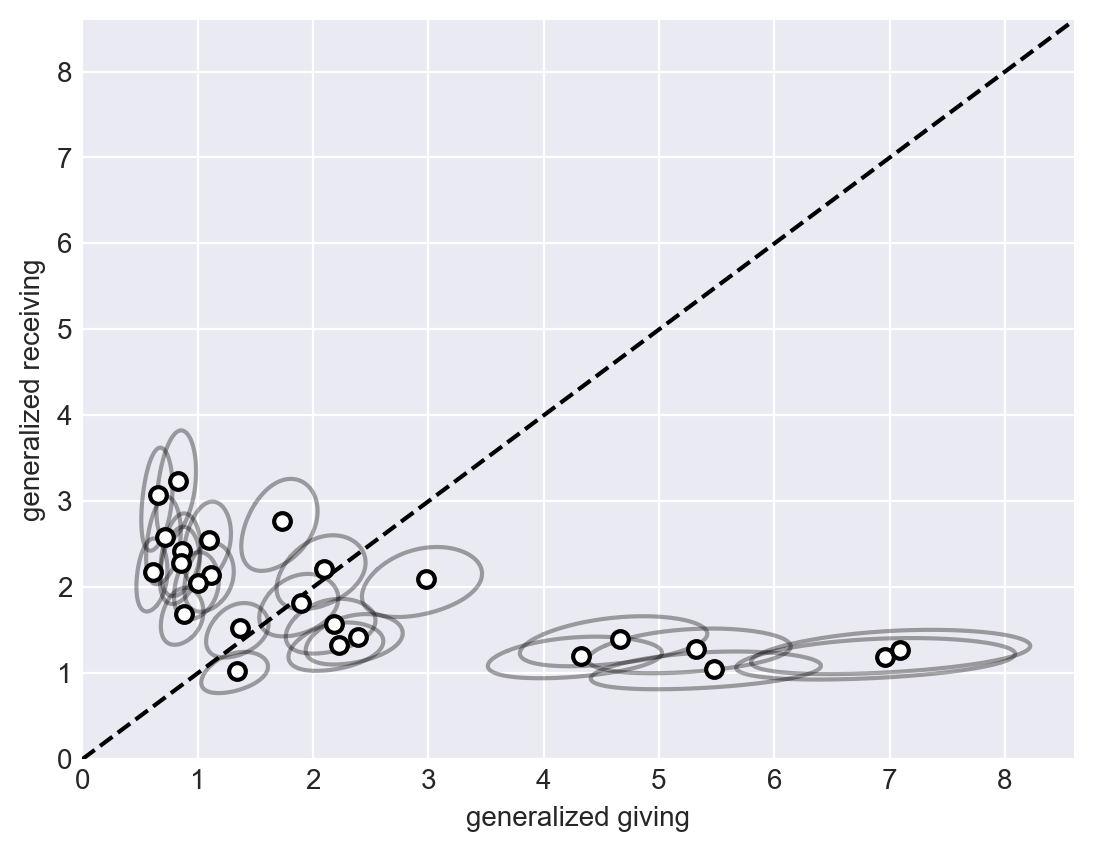

In [456]:
fig, ax = plt.subplots()
ax.set_xlim(0, 8.6)
ax.set_ylim(0, 8.6)
ax.set_xlabel("generalized giving")
ax.set_ylabel("generalized receiving")
ax.plot([0, 8.6], [0, 8.6], "k--")

level = 0.5
scale = np.sqrt(chi2.ppf(.25, df=2))
theta = np.linspace(0, 2 * np.pi, 200)

for i in range(25):
    g_flat = g[i].ravel()
    r_flat = r[i].ravel()
    Sigma_i = np.cov(np.stack([g_flat, r_flat]))
    Mu_i = np.array([g_flat.mean(), r_flat.mean()])
    evals, evecs = np.linalg.eigh(Sigma_i)
    evals = np.maximum(evals, 1e-10)
    log_pts = Mu_i + scale * (
        np.sqrt(evals[0]) * np.outer(np.cos(theta), evecs[:, 0])
        + np.sqrt(evals[1]) * np.outer(np.sin(theta), evecs[:, 1])
    )
    exp_pts = np.exp(log_pts)
    ax.plot(exp_pts[:, 0], exp_pts[:, 1], color="black", alpha=0.35)

ax.scatter(Eg_mu, Er_mu, facecolors="white", edgecolors="black", linewidths=1.5, zorder=5);


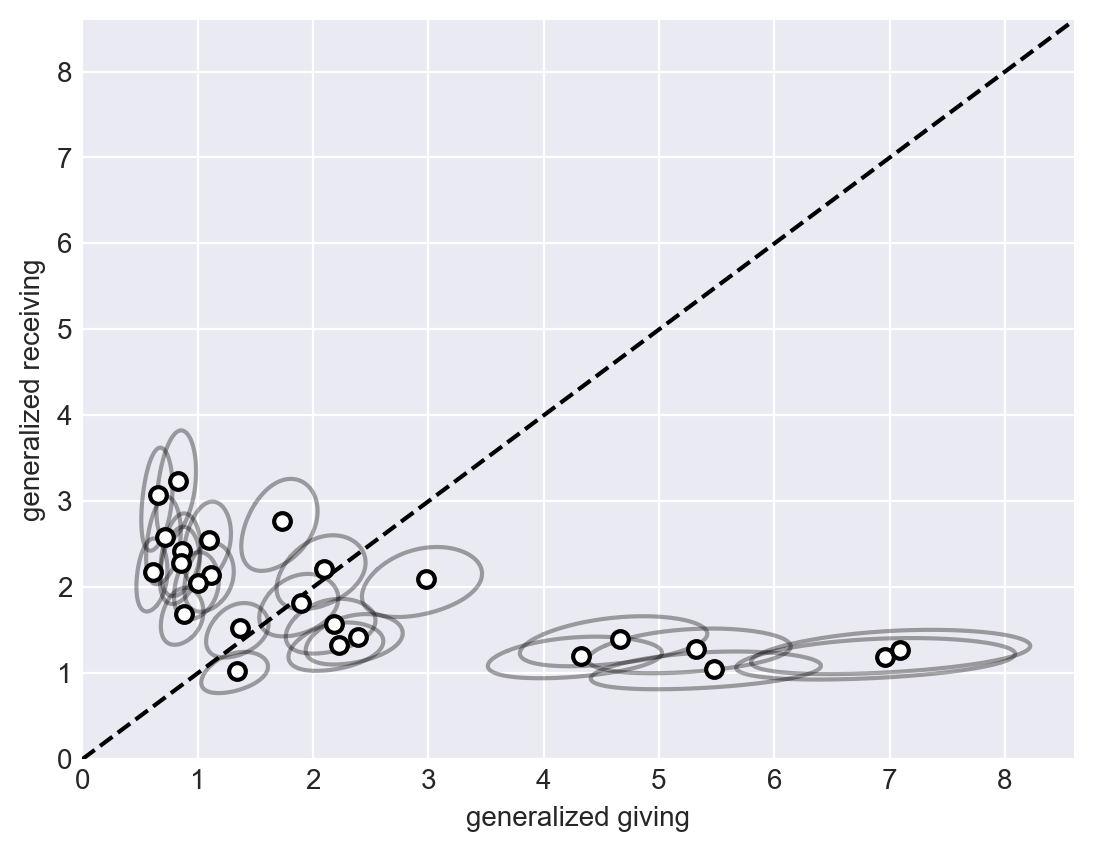

In [459]:
plt.figure();
plt.xlim(0,8.6)
plt.ylim(0,8.6)
plt.xlabel('generalized giving')
plt.ylabel('generalized receiving')
plt.plot([plt.xlim()[0], plt.xlim()[1]], [plt.ylim()[0], plt.ylim()[1]], 'k--')


level = 0.5
scale = np.sqrt(chi2.ppf(.25, df=2))
theta = np.linspace(0, 2 * np.pi, 200)

for i in range(25):
    g_flat = g[i].ravel()
    r_flat = r[i].ravel()
    Sigma_i = np.cov(np.stack([g_flat, r_flat]))
    Mu_i = np.array([g_flat.mean(), r_flat.mean()])
    evals, evecs = np.linalg.eigh(Sigma_i)
    evals = np.maximum(evals, 1e-10)
    log_pts = Mu_i + scale * (
        np.sqrt(evals[0]) * np.outer(np.cos(theta), evecs[:, 0])
        + np.sqrt(evals[1]) * np.outer(np.sin(theta), evecs[:, 1])
    )
    exp_pts = np.exp(log_pts)
    plt.plot(exp_pts[:, 0], exp_pts[:, 1], color="black", alpha=0.35)

plt.scatter(Eg_mu, Er_mu, facecolors="white", edgecolors="black", linewidths=1.5, zorder=5);


#### Code 14.35

In [447]:
trace_m14_7

pm.summary(trace_m14_7, var_names = ['Rho_corr', 'Rho_stds'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"Rho_corr[0, 0]",1.000,0.000,1.000,1.000,0.000,0.000,2000.0,2000.0,NaN
"Rho_corr[0, 1]",0.881,0.034,0.821,0.943,0.002,0.001,393.0,836.0,1.00
"Rho_corr[1, 0]",0.881,0.034,0.821,0.943,0.002,0.001,393.0,836.0,1.00
"Rho_corr[1, 1]",1.000,0.000,1.000,1.000,0.000,0.000,2083.0,1552.0,1.00
Rho_stds[0],1.072,0.067,0.933,1.190,0.003,0.002,465.0,906.0,1.01
Rho_stds[1],1.125,0.068,1.001,1.253,0.003,0.002,605.0,910.0,1.01


#### Code 14.36

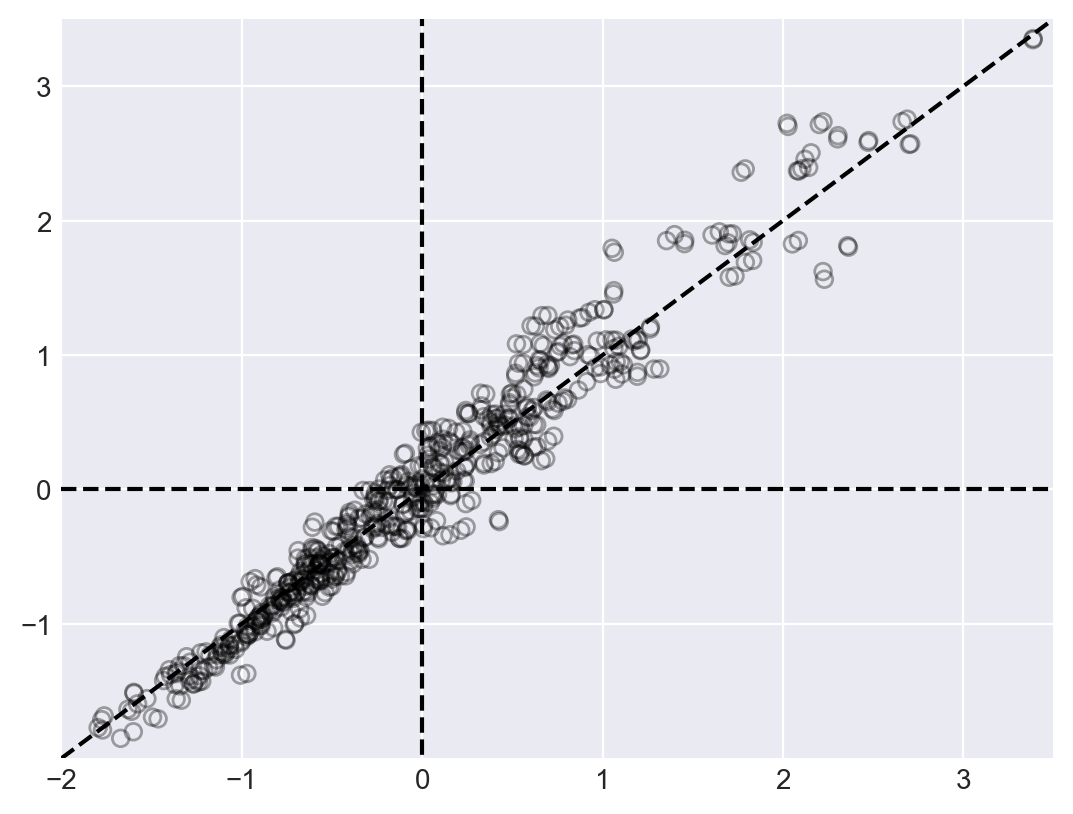

In [480]:
dy1 = post.d.sel(d_dim_1 = 0).mean(axis = 1)
dy2 = post.d.sel(d_dim_1 = 1).mean(axis = 1)
plt.scatter(dy1, dy2, facecolor='none', edgecolor='black', alpha=.35)
plt.plot([-2, 4], [-2, 4], linestyle='--', color='black')  
plt.hlines(0,-2,4, color = 'black', linestyles='--')
plt.vlines(0,-2.3,4.3, color = 'black', linestyles='--')
plt.xlim(-1.7, 3.5)
plt.xticks([-2,-1,0,1,2,3])
plt.ylim(-2,3.5)
plt.yticks([-1,0,1,2,3]);


#### Code 14.37

In [9]:
Dmat = round(pd.read_csv('data/islandsDistMatrix.csv', index_col = 0),1)
Dmat

,Ml,Ti,SC,Ya,Fi,Tr,Ch,Mn,To,Ha
Malekula,0.0,0.5,0.6,4.4,1.2,2.0,3.2,2.8,1.9,5.7
Tikopia,0.5,0.0,0.3,4.2,1.2,2.0,2.9,2.7,2.0,5.3
Santa Cruz,0.6,0.3,0.0,3.9,1.6,1.7,2.6,2.4,2.3,5.4
Yap,4.4,4.2,3.9,0.0,5.4,2.5,1.6,1.6,6.1,7.2
Lau Fiji,1.2,1.2,1.6,5.4,0.0,3.2,4.0,3.9,0.8,4.9
Trobriand,2.0,2.0,1.7,2.5,3.2,0.0,1.8,0.8,3.9,6.7
Chuuk,3.2,2.9,2.6,1.6,4.0,1.8,0.0,1.2,4.8,5.8
Manus,2.8,2.7,2.4,1.6,3.9,0.8,1.2,0.0,4.6,6.7
Tonga,1.9,2.0,2.3,6.1,0.8,3.9,4.8,4.6,0.0,5.0
Hawaii,5.7,5.3,5.4,7.2,4.9,6.7,5.8,6.7,5.0,0.0


#### Code 14.38

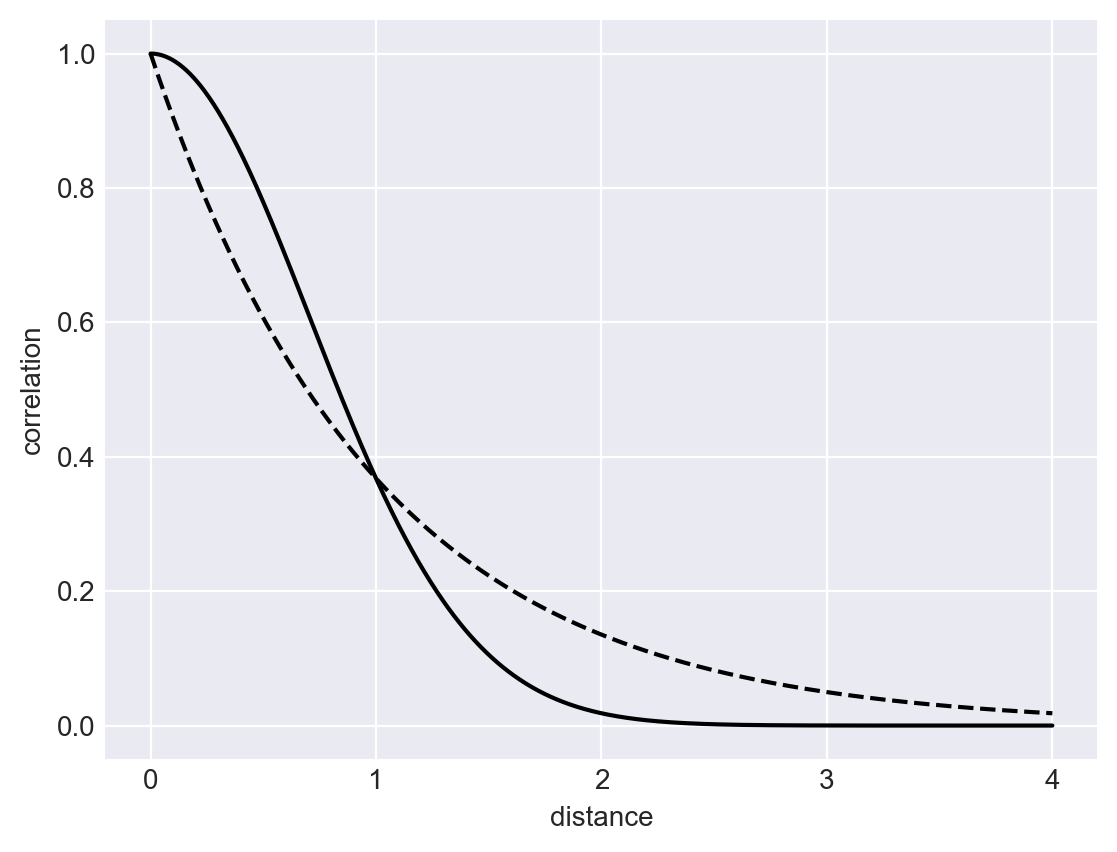

In [4]:
x = np.linspace(0, 4, 1000)
plt.plot(x, np.exp(-x), linestyle='--',color='black')
plt.plot(x, np.exp(-x**2), color='black')
plt.xlabel('distance')
plt.xticks([0,1,2,3,4])
plt.ylabel('correlation');

#### Code 14.39

In [59]:
d = pd.read_csv('data/Kline.csv', sep = ';')
d['society'] = d.index

dat_list = pd.DataFrame({
    'T' : d.total_tools,
    'P' : d.population,
    'society': d.society,
})



with pm.Model() as m14_8:
    ## priors
    rhosq = pm.Exponential('rhosq', .5)
    etasq = pm.Exponential('etasq', 2)
    a = pm.Exponential('a', 1)
    b = pm.Exponential('b', 1)
    g = pm.Exponential('g', 1)

    ## Gaussian Process
    SIGMA = etasq * pm.math.exp(-rhosq * Dmat.values**2) + np.eye(10) * 0.01

    k = pm.MvNormal('k', np.zeros(10), cov = SIGMA)

    ## linear model
    lambda_ = pm.Deterministic('lambda_', (a * dat_list.P.values**b / g * np.exp(k[dat_list.society])))
    T = pm.Poisson('T',lambda_, observed= dat_list['T'])


    trace_m14_8 = pm.sample(chains = 4, tune = 1000, cores = 1, idata_kwargs={'log_likelihood': True})



Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [rhosq, etasq, a, b, g, k]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 128 seconds.
There were 220 divergences after tuning. Increase `target_accept` or reparameterize.


#### Code 14.40

In [23]:
pm.summary(trace_m14_8, var_names = ['k','g','b','a','etasq','rhosq'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
k[0],-0.174,0.290,-0.732,0.363,0.016,0.012,354.0,305.0,1.01
k[1],-0.012,0.285,-0.573,0.501,0.016,0.012,344.0,376.0,1.01
k[2],-0.060,0.273,-0.621,0.429,0.016,0.012,306.0,299.0,1.01
k[3],0.363,0.251,-0.062,0.890,0.016,0.012,269.0,352.0,1.01
k[4],0.082,0.247,-0.432,0.508,0.016,0.012,261.0,267.0,1.01
k[5],-0.378,0.249,-0.883,0.064,0.014,0.011,313.0,314.0,1.01
k[6],0.153,0.241,-0.290,0.652,0.016,0.012,260.0,191.0,1.01
k[7],-0.201,0.245,-0.718,0.240,0.015,0.010,294.0,237.0,1.01
k[8],0.277,0.235,-0.186,0.725,0.017,0.013,258.0,176.0,1.02
k[9],-0.143,0.352,-0.794,0.559,0.022,0.018,312.0,293.0,1.01


#### Code 14.41

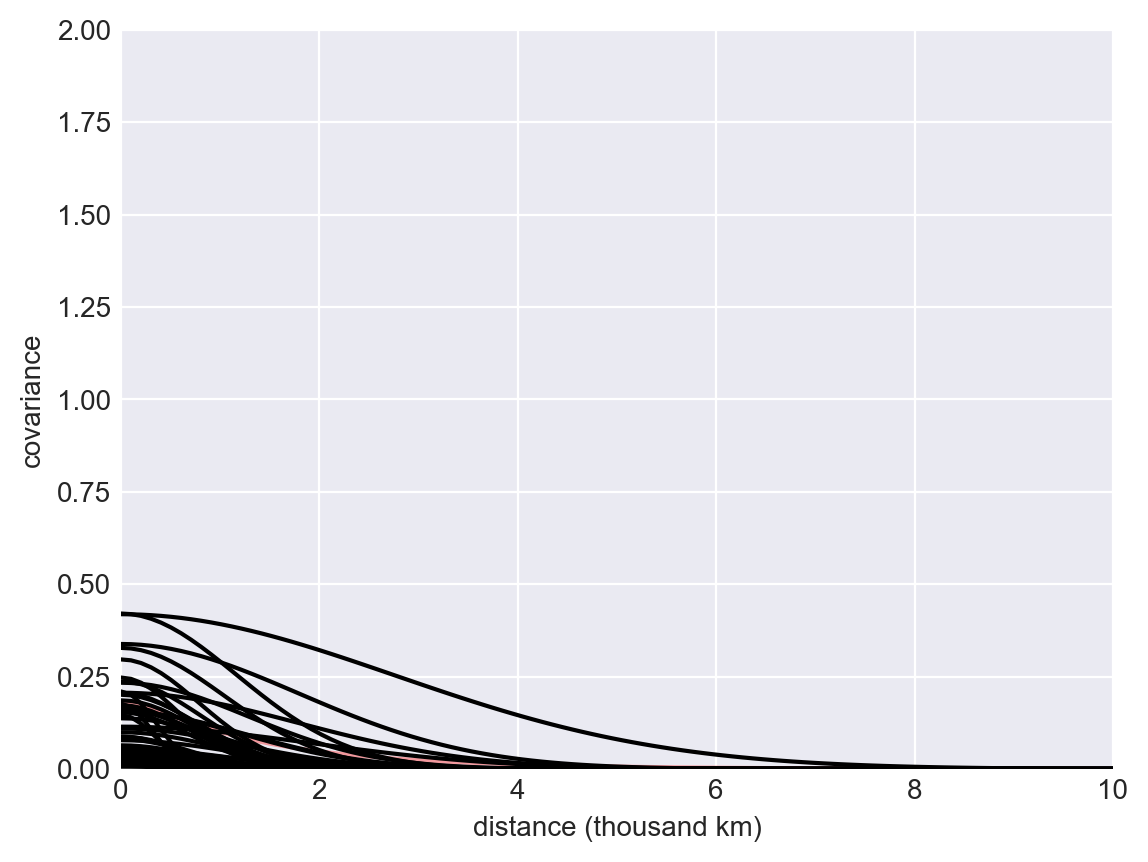

In [60]:
post = trace_m14_8.posterior

plt.figure()
plt.xlabel('distance (thousand km)')
plt.ylabel('covariance')
plt.xlim (0,10)
plt.ylim(0,2)

x_seq = np.linspace(0,10,100)
pmcov = post.etasq.values.flatten()[None,:] * np.exp(-post.rhosq.values.flatten()[None,:] * x_seq[:,None] ** 2)
pmcov_mu = pmcov.mean(axis=1)

plt.plot(x_seq, pmcov_mu, color = 'red', alpha = .35)

for i in range(50):
    plt.plot(x_seq, post.etasq.values.flatten()[i] * np.exp(-post.rhosq.values.flatten()[i] * x_seq ** 2), color = 'black')

#### Code 14.41

In [61]:
K = np.zeros([10,10])

for i in range(10):
    for j in range(10):
        K[i,j] = post.etasq.median() * np.exp(-post.rhosq.median() * Dmat.iloc[i,j] ** 2)
np.fill_diagonal(K,post.etasq.median().values + .01)

#### Code 14.43

In [56]:
Rho = pd.DataFrame(np.round(K / np.outer(np.sqrt(np.diag(K)),np.sqrt(np.diag(K))),2)) #No easy translation of cov2cor in python
Rho.columns = ["Ml","Ti","SC","Ya","Fi","Tr","Ch","Mn","To","Ha"]
Rho.index = ["Ml","Ti","SC","Ya","Fi","Tr","Ch","Mn","To","Ha"]
Rho

,Ml,Ti,SC,Ya,Fi,Tr,Ch,Mn,To,Ha
Ml,1.00,0.77,0.71,0.00,0.31,0.04,0.00,0.00,0.06,0.0
Ti,0.77,1.00,0.87,0.00,0.31,0.04,0.00,0.00,0.04,0.0
SC,0.71,0.87,1.00,0.00,0.13,0.10,0.01,0.01,0.02,0.0
Ya,0.00,0.00,0.00,1.00,0.00,0.01,0.13,0.13,0.00,0.0
Fi,0.31,0.31,0.13,0.00,1.00,0.00,0.00,0.00,0.57,0.0
Tr,0.04,0.04,0.10,0.01,0.00,1.00,0.08,0.57,0.00,0.0
Ch,0.00,0.00,0.01,0.13,0.00,0.08,1.00,0.31,0.00,0.0
Mn,0.00,0.00,0.01,0.13,0.00,0.57,0.31,1.00,0.00,0.0
To,0.06,0.04,0.02,0.00,0.57,0.00,0.00,0.00,1.00,0.0
Ha,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.0


#### Code 14.44

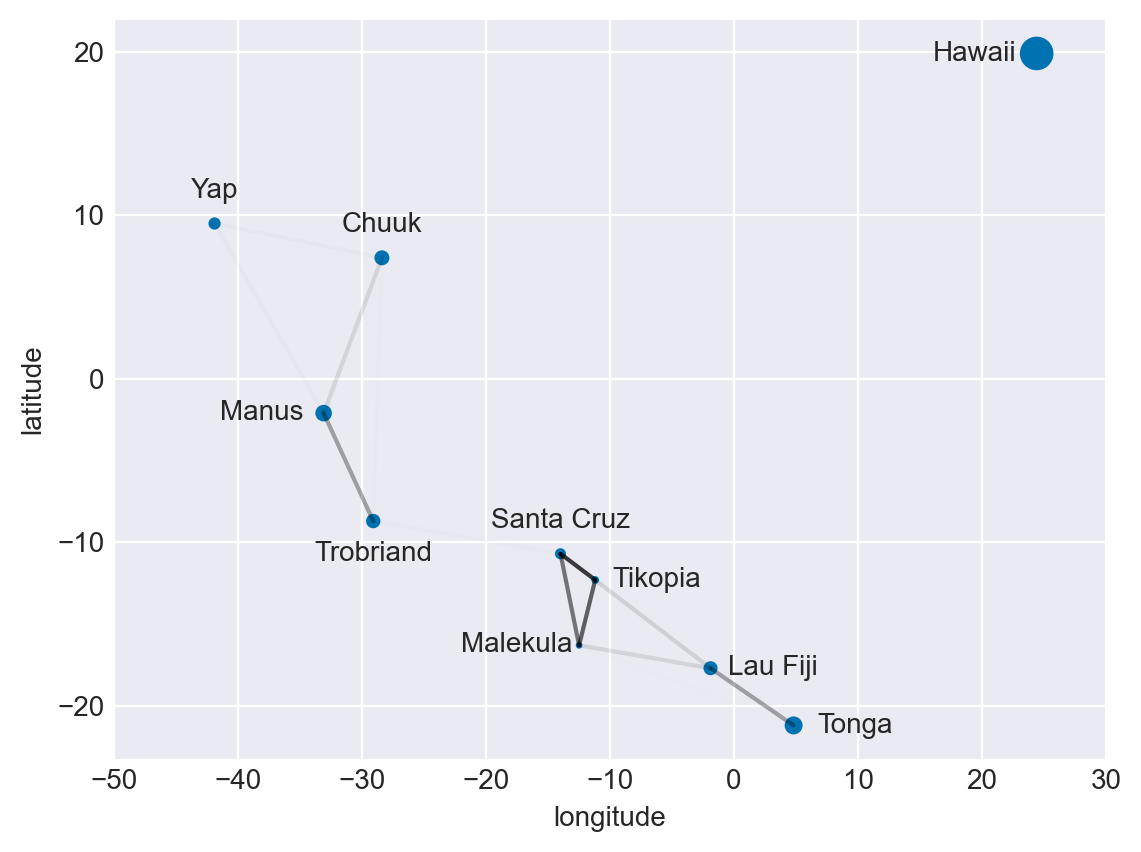

In [73]:
d = pd.read_csv('data/Kline2.csv')


# scale point size to logpop
d['logpop'] = np.log(d.population)
psize = d.logpop.values / d.logpop.max()
psize = np.exp(psize * 1.5) - 2

# plot raw data and labels
plt.scatter(d.lon2, d.lat, s=(psize**2) * 20)
plt.gca().set(xlabel="longitude", ylabel="latitude", xlim=(-50, 30))
labels = d.culture.values
pos = [2, 4, 3, 3, 4, 1, 3, 2, 4, 2]
for i in range(len(labels)):
    dx = [0, -5, 0, 5][pos[i] - 1]
    dy = [-2, 0, 2, 0][pos[i] - 1]
    plt.annotate(
        labels[i],
        (d.lon2[i], d.lat[i]),
        (d.lon2[i] + dx, d.lat[i] + dy),
        ha="center",
        va="center",
    )

for i in range(10):
    for j in range(10):
        if i < j:
            plt.plot([d.lon2[i],d.lon2[j]], [d.lat[i], d.lat[j]], color = 'black', alpha = Rho.iloc[i,j]**2)


#### Code 14.45

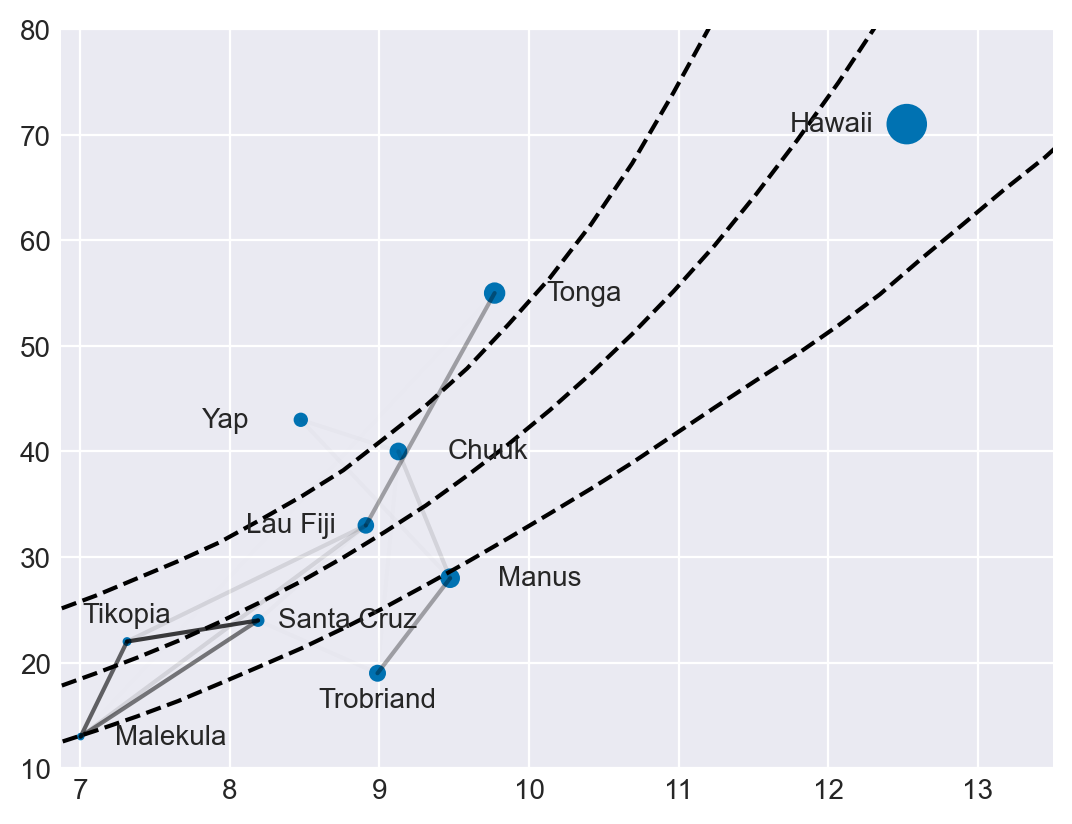

In [120]:
logpop_seq = np.linspace(6, 14, 30)
_lambda = [post.a.values.flatten() * np.exp(lp) ** post.b.values.flatten()  / post.g.values.flatten() for lp in logpop_seq]
lambda_median = np.median(_lambda,1)
lambda_p10, lambda_p90 = np.percentile(_lambda, [10, 90], axis=1)
plt.scatter(d.logpop, d.total_tools, s = psize**2 * 30)
plt.ylim(10,80)
plt.xlim(6.87,13.5)
pos = [4, 3, 4, 2, 2, 1, 4, 4, 4, 2]
for i in range(len(labels)):
    dx = [0, -0.5, 0, 0.6][pos[i] - 1]
    dy = [-2.5, 0, 2.5, 0][pos[i] - 1]
    plt.annotate(
        labels[i],
        (d.logpop[i], d.total_tools[i]),
        (d.logpop[i] + dx, d.total_tools[i] + dy),
        va="center",
        ha="center",
        zorder=3,
    )
plt.plot(logpop_seq, lambda_median, 'k--',color = 'black');
plt.plot(logpop_seq, lambda_p10, 'k--',color = 'black')
plt.plot(logpop_seq, lambda_p90, 'k--',color = 'black')


for i in range(10):
    for j in range(10):
        if i < j:
            plt.plot([d.logpop[i],d.logpop[j]], [d.total_tools[i], d.total_tools[j]], color = 'black', alpha = Rho.iloc[i,j]**2)


#### Code 14.46

In [127]:
np.linalg.cholesky(Dmat.values)

LinAlgError: Matrix is not positive definite

In [132]:
import pytensor.tensor as pt

with pm.Model() as m14_8nc:
    ## priors
    rhosq = pm.Exponential('rhosq', .5)
    etasq = pm.Exponential('etasq', 2)
    a = pm.Exponential('a', 1)
    b = pm.Exponential('b', 1)
    g = pm.Exponential('g', 1)

    ## Gaussian Process
    SIGMA = etasq * pm.math.exp(-rhosq * Dmat.values**2) + np.eye(10) * 0.01
    L_SIGMA = pt.linalg.cholesky(SIGMA)

    z = pm.Normal('z', 0,1, shape = 10) 
    k = pm.Deterministic('k', L_SIGMA @ z)



    ## linear model
    lambda_ = pm.Deterministic('lambda_', (a * dat_list.P.values**b / g * np.exp(k[dat_list.society])))
    T = pm.Poisson('T',lambda_, observed= dat_list['T'])


    trace_m14_8 = pm.sample(chains = 4, tune = 1000, cores = 1, idata_kwargs={'log_likelihood': True})


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [rhosq, etasq, a, b, g, z]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 100 seconds.
There were 249 divergences after tuning. Increase `target_accept` or reparameterize.


#### Code 14.47

_The ape package doesnt really exist but ive donloaded a version of the image here_

![Ape phylogeny](data/ape_nex.png)

#### Code 14.48

In [12]:
d = pd.read_csv('data/Primates301.csv', sep = ';')
dstan = d.dropna(subset=['group_size', 'body', 'brain'])
spp_obs = dstan.name

#### Code 14.49

In [43]:
N_spp = dstan.shape[0]
M = scaler.fit_transform(np.log(dstan[['body']]))
B = scaler.fit_transform(np.log(dstan[['brain']]))
G = scaler.fit_transform(np.log(dstan[['group_size']]))
Imat = np.eye(dstan.shape[0])

with pm.Model() as m14_9:
    sigma_sq = pm.Exponential('sigma_sq', 1)
    bM = pm.Normal('bM', 0,.5)
    bG = pm.Normal('bG', 0,.5)
    a = pm.Normal('a', 0,1)
    SIGMA  = pm.Deterministic('SIGMA', Imat * sigma_sq)
    mu = pm.Deterministic('mu', a + bM*M + bG*G)
    B = pm.MvNormal('B', mu = mu, cov = SIGMA, observed = B)
    trace_m14_9 = pm.sample(cores = 1, idata_kwargs={'log_likelihood':True})



Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [sigma_sq, bM, bG, a]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 150 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


In [44]:
pm.summary(trace_m14_9, var_names = ['a', 'bG', 'bM', 'sigma_sq'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,0.000,0.001,-0.003,0.002,0.0,0.0,2424.0,1416.0,1.0
bG,0.122,0.002,0.119,0.126,0.0,0.0,1131.0,1417.0,1.0
bM,0.895,0.002,0.892,0.898,0.0,0.0,1401.0,1583.0,1.0
sigma_sq,0.045,0.000,0.045,0.046,0.0,0.0,1992.0,1318.0,1.0


#### Code 14.50

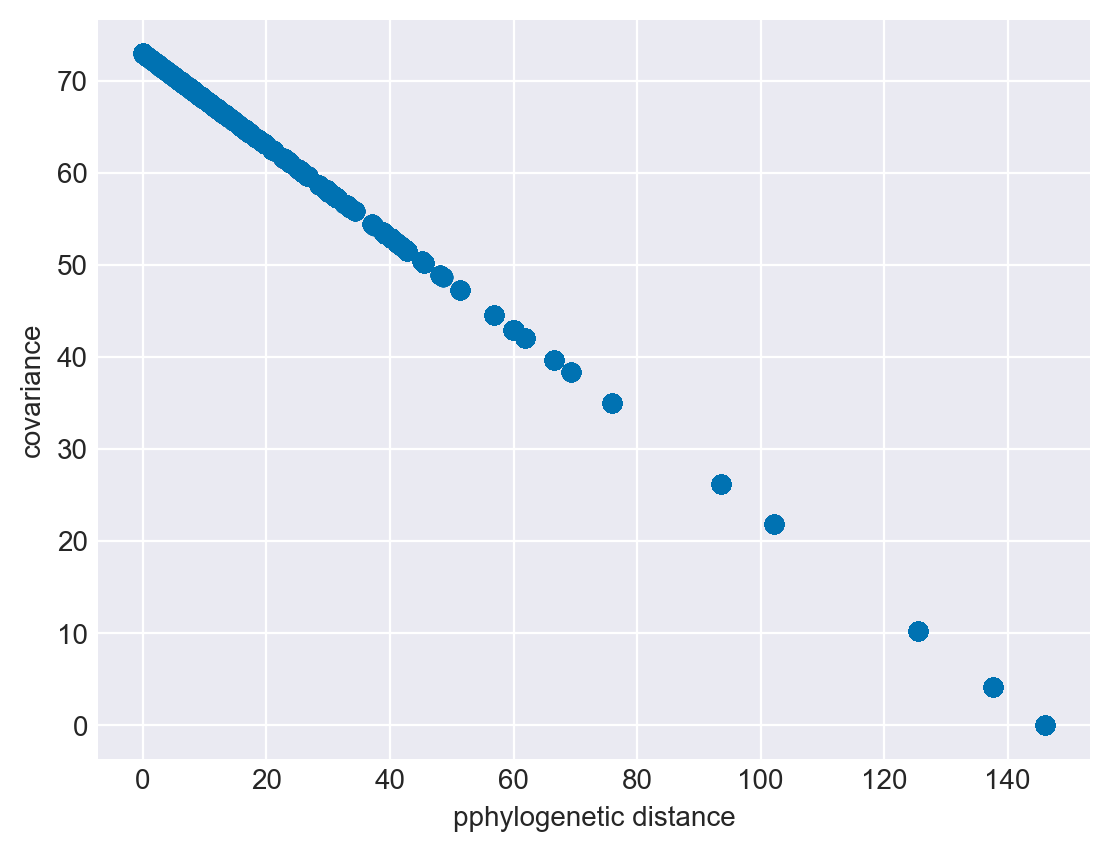

In [78]:
V = pd.read_csv('data/Primates301_vcov_matrix.csv', index_col = 0)
Dmat = pd.read_csv('data/Primates301_distance_matrix.csv', index_col = 0)
plt.figure()
plt.scatter(Dmat.values.reshape(-1), V.values.reshape(-1))
plt.ylabel('covariance')
plt.xlabel('pphylogenetic distance');

#### Code 14.51

In [79]:
V = V.loc[spp_obs, spp_obs].values
R = V / np.max(V)
B = scaler.fit_transform(np.log(dstan[['brain']]))

with pm.Model() as m14_10:
    sigma_sq = pm.Exponential('sigma_sq', 1)
    bM = pm.Normal('bM', 0,.5)
    bG = pm.Normal('bG', 0,.5)
    a = pm.Normal('a', 0,1)
    SIGMA  = pm.Deterministic('SIGMA', R * sigma_sq)
    mu = pm.Deterministic('mu', a + bM*M + bG*G)
    B = pm.MvNormal('B', mu = mu, cov = SIGMA, observed = B)
    trace_m14_10 = pm.sample(cores = 1, idata_kwargs={'log_likelihood':True})
pm.summary(trace_m14_10, var_names = ['a','bG','bM','sigma_sq'])

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [sigma_sq, bM, bG, a]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 164 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,0.000,0.001,-0.003,0.003,0.0,0.0,1760.0,1409.0,1.0
bG,0.122,0.002,0.119,0.126,0.0,0.0,1417.0,1602.0,1.0
bM,0.895,0.002,0.892,0.898,0.0,0.0,1656.0,1687.0,1.0
sigma_sq,0.002,0.000,0.002,0.002,0.0,0.0,2134.0,1469.0,1.0


#### Code 14.52

In [ ]:
B = scaler.fit_transform(np.log(dstan[['brain']]))
Dmat_scaled = Dmat / Dmat.values.max()
with pm.Model() as m14_11:
    rhosq = pm.TruncatedNormal('rhosq', mu=3, sigma=0.25, lower=0)
    etasq = pm.TruncatedNormal('etasq', mu=1, sigma=0.25, lower=0)

    bM = pm.Normal('bM', 0,.5)
    bG = pm.Normal('bG', 0,.5)

    a = pm.Normal('a', 0,1)
    
    SIGMA = etasq * pm.math.exp(-rhosq * Dmat_scaled.values) + np.eye(int(Dmat_scaled.shape[0])) * 0.01

    mu = pm.Deterministic('mu', a + bM*M + bG*G)
    B = pm.MvNormal('B', mu = mu, cov = SIGMA, observed = B)
    trace_m14_11 = pm.sample(cores = 1, idata_kwargs={'log_likelihood':True})
pm.summary(trace_m14_11, var_names = ['a','bG','bM','etasq', 'rhosq'])

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [rhosq, etasq, bM, bG, a]


Output()

#### Code 14.53

In [ ]:
pm.summary(trace_m14_11, var_names = ['a','bG','bM','etasq', 'rhosq'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,0.000,0.017,-0.033,0.031,0.000,0.0,1693.0,1406.0,1.0
bG,0.123,0.023,0.079,0.164,0.001,0.0,1586.0,1464.0,1.0
bM,0.893,0.023,0.850,0.938,0.001,0.0,1797.0,1511.0,1.0
etasq,0.047,0.005,0.038,0.058,0.000,0.0,1856.0,1530.0,1.0
rhosq,0.000,0.000,0.000,0.000,0.000,0.0,1165.0,767.0,1.0


Text(0.2, 0.1, 'posterior')

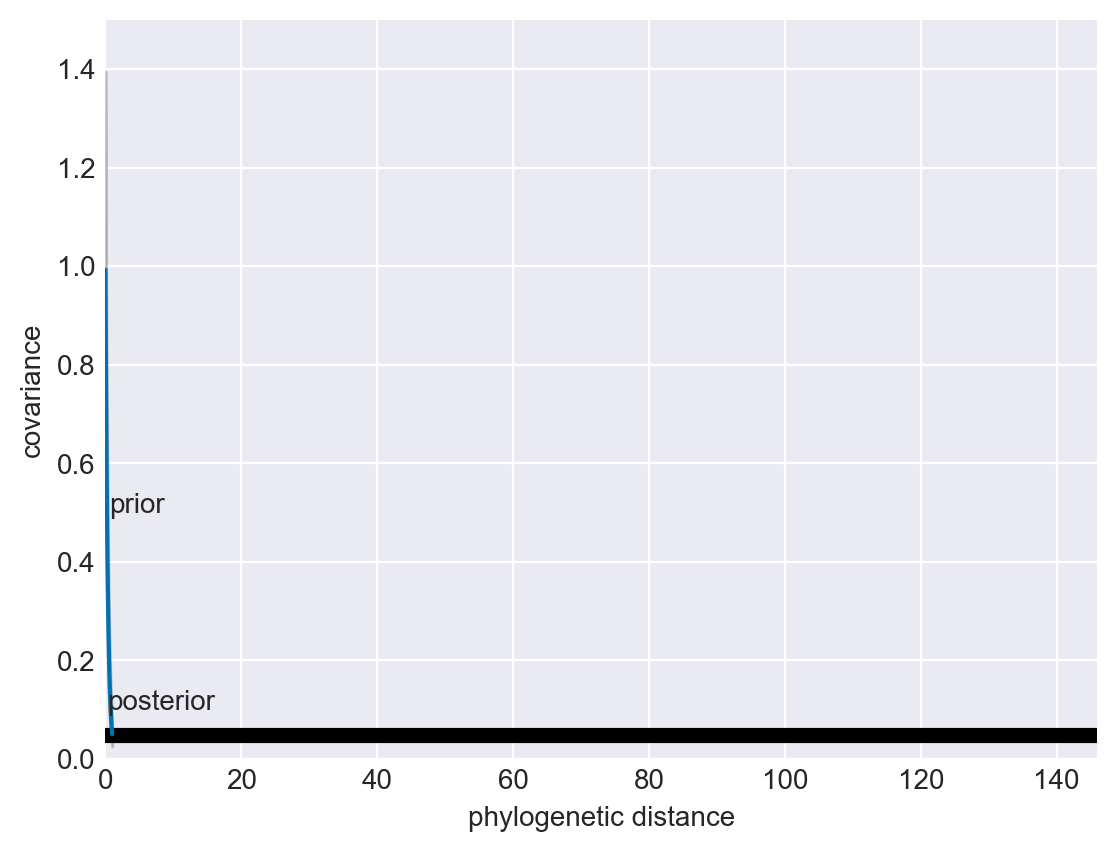

In [ ]:
post = trace_m14_11.posterior

plt.figure()
plt.xlim(0, Dmat.values.max())
plt.ylim(0,1.5)
plt.xlabel('phylogenetic distance')
plt.ylabel('covariance')


x = np.linspace(0, np.max(Dmat.values), 101)
for i in range(30):
    plt.plot(x, post.etasq.values.flatten()[i] * np.exp(-post.rhosq.values.flatten()[i]* x), color = 'black')

eta = abs(np.random.normal(1,.25,1000))
rho = abs(np.random.normal(3,.25,1000))

d_seq = np.linspace(0,1,50)
K = [eta * np.exp(-rho * d) for d in d_seq ]
plt.plot(d_seq, np.mean(K, axis =1))
plt.fill_between(d_seq, *np.percentile(K, [5.5,94.5], axis = 1), alpha =.2, color = 'black')
plt.text(.5, .5, 'prior')
plt.text(.2, .1, 'posterior')